In [2]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
import sys

curr_dir = os.path.abspath(os.getcwd())
PROJECT_DIR = os.path.abspath(os.path.join(curr_dir, '..', '..', '..'))
Unlearn_Simple_DIR = os.path.join(PROJECT_DIR, 'Unlearn-Simple')
MUSE_DIR = os.path.join(Unlearn_Simple_DIR, 'MUSE')

# clean GPU mem
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    
# Import the evaluation function from eval.py
sys.path.append(MUSE_DIR)
# sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import eval

/home/liranc6/miniconda3/envs/unlearn_simple/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
MUSE_SRC_DIR = os.path.join(MUSE_DIR, 'src')
sys.path.append(MUSE_SRC_DIR)
import eval_with_ILL


In [ ]:
from eval import load_then_eval_models 

# Load your single model and tokenizer
model_name = "OPTML-Group/SimNPO-MUSE-News-llama-2-7b"
tokenizer_dir = "meta-llama/Llama-2-7b-hf"  # Or use model_name if appropriate

tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir)

# metrics = ["verbmem_f", "privleak", "knowmem_f", "knowmem_r"]  # Optional
out_file_full = os.path.join(os.getcwd(), "simnpo_news_eval.csv")

# params = {
#     "model_dirs": ["OPTML-Group/SimNPO-MUSE-News-llama-2-7b"],
#     "names": ["SimNPO-MUSE-News"],
#     "corpus": "news",
#     "out_file": out_file_full,
#     "metrics": ['loss_landscape'], #["privleak", "verbmem_f", "knowmem_f", "knowmem_r", "loss_landscape"],
#     "tokenizer_dir": "meta-llama/Llama g-2-7b-hf",
#     "temp_dir": "temp",
#     "DEBUG": True
# }

# # model_name='distilgpt2-finetuned-wikitext2'
# create_new_file = True

# forget_data, retain_data, holdout_data, model, tokenizer, loss_landscape = load_then_eval_models(**params)

In [ ]:
import json

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', 'src')))
import input_loss_landscape.utils as input_loss_landscape_utils

raw_or_privleak = 'raw'

forget_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/forget.json')
if raw_or_privleak == 'raw':
    retain_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/retain1.json')
else:
    retain_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/retain.json')
holdout_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/holdout.json')

forget_data = eval_with_ILL.read_json(forget_file)
retain_data = eval_with_ILL.read_json(retain_file)
holdout_data = eval_with_ILL.read_json(holdout_file)

subset_len = -1
forget_data = forget_data[:subset_len]
retain_data = retain_data[:subset_len]
holdout_data = holdout_data[:subset_len]

In [ ]:
sys.path.append(PROJECT_DIR)

import src.utils as project_utils

In [ ]:
from input_loss_landscape.utils import *

In [ ]:
from input_loss_landscape.utils import new_ILL_eval

sub_len = 500
datasets = {'forget': {'name': 'forget', 'data': forget_data[:sub_len]},
            'retain': {'name': 'retain', 'data': retain_data[:sub_len]},
            'holdout': {'name': 'holdout', 'data': holdout_data[:sub_len]}
            }

perc_of_tokens_to_replace=0.1
n_tokens = int(300*perc_of_tokens_to_replace)

strategy = {'name': 'embeddings', 'peak_top_k': 20, 'n_tokens': n_tokens, 'max_neighbors': 15}

cosine_similarities_file = os.path.join(PROJECT_DIR,
                                            'models', 
                                            'distilgpt2-finetuned-wikitext2',
                                            'embeddings', 
                                            'token_knn_mapping_70_cosine.pth'
                                            )

new_ILL_eval_kwargs = {
    'model_name': model_name,
    'model': model,
    'tokenizer': tokenizer,
    'datasets': datasets,
    'prompt_column': 'text',
    'create_new_neighbors_file': False,
    'showplts': False,
    'cosine_similarities_file': cosine_similarities_file,
    'plots_output_dir': None,
    'strategy': strategy,
    'output_dirs': {'neighbors': f'{raw_or_privleak}'}
}
features_dict = new_ILL_eval(new_ILL_eval_kwargs)

working on forget subset


Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/forget.json already exists. Skipping generation.
Loaded 491 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/forget.json.
Extracting features


Batches: 100%|██████████| 116/116 [00:05<00:00, 22.83it/s]


working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/retain.json already exists. Skipping generation.
Loaded 484 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/retain.json.
Extracting features


Batches: 100%|██████████| 114/114 [00:04<00:00, 24.61it/s]


working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/holdout.json already exists. Skipping generation.
Loaded 472 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/holdout.json.
Extracting features


Batches: 100%|██████████| 111/111 [00:04<00:00, 26.26it/s]


In [ ]:
forget_tensor = features_dict['forget']['unnormalized_features_tensor']
retain_tensor = features_dict['retain']['unnormalized_features_tensor']
holdout_tensor = features_dict['holdout']['unnormalized_features_tensor']

min_examples_num = min(len(forget_tensor), len(retain_tensor), len(holdout_tensor))
forget_tensor = forget_tensor[:min_examples_num]
retain_tensor = retain_tensor[:min_examples_num]
holdout_tensor = holdout_tensor[:min_examples_num]

In [ ]:
forget_tensor.shape, retain_tensor.shape, holdout_tensor.shape

(torch.Size([472, 15]), torch.Size([472, 15]), torch.Size([472, 15]))

In [ ]:
print(f"{type(features_dict)=}, {features_dict.keys()=}, {features_dict['forget'].keys()=}, {features_dict['forget']['unnormalized_features_tensor'].shape=}")

type(features_dict)=<class 'dict'>, features_dict.keys()=dict_keys(['forget', 'retain', 'holdout']), features_dict['forget'].keys()=dict_keys(['unnormalized_features_tensor', 'features_names']), features_dict['forget']['unnormalized_features_tensor'].shape=torch.Size([491, 15])


In [ ]:
plots_base_dir = "loss_landscape_plots"
plots = eval_with_ILL.plot_landscape_results_from_features(features_dict, plot_base_dir=plots_base_dir)

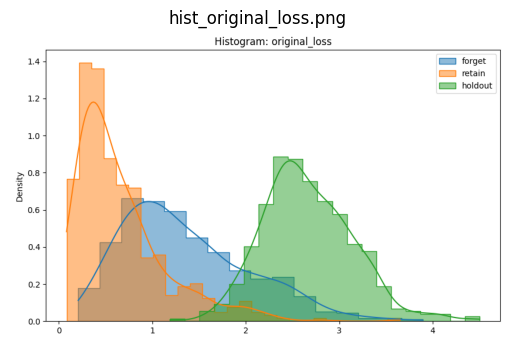

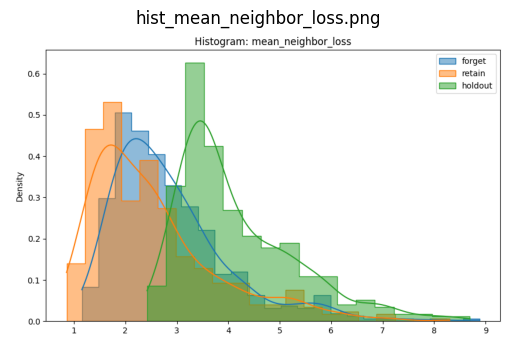

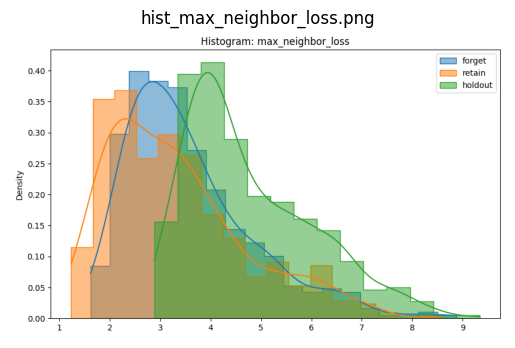

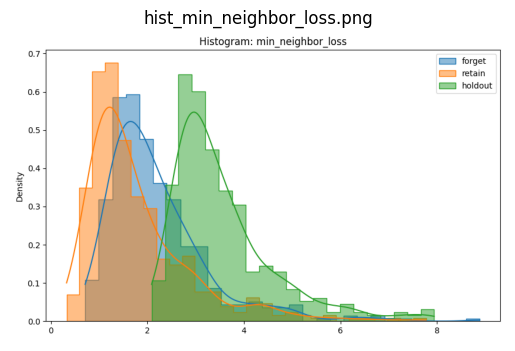

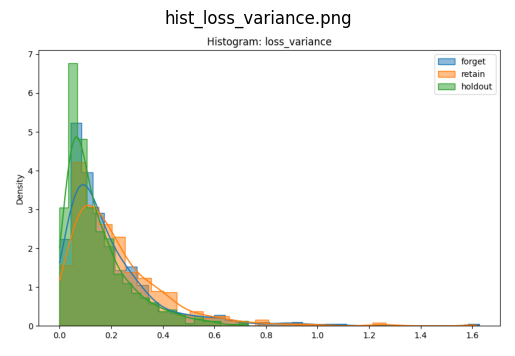

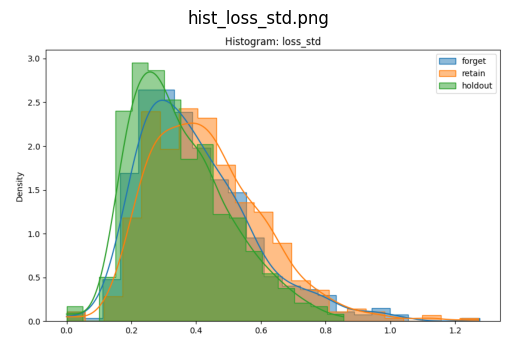

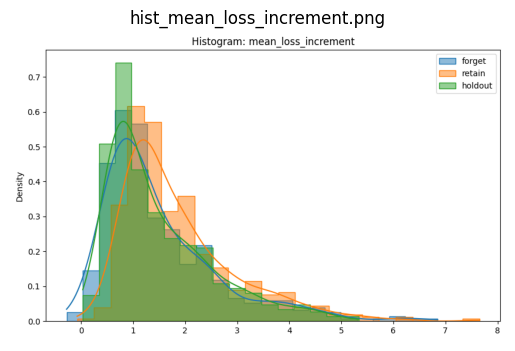

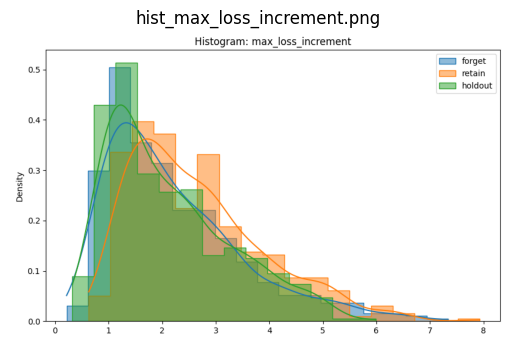

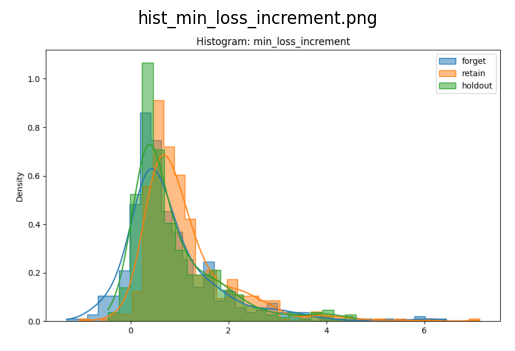

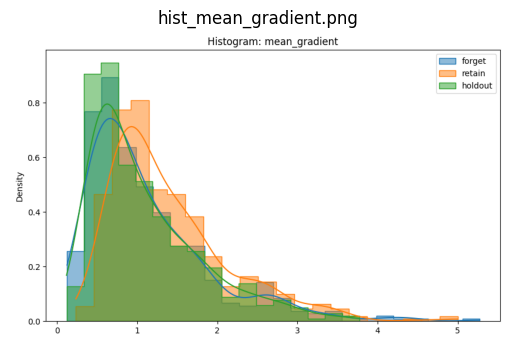

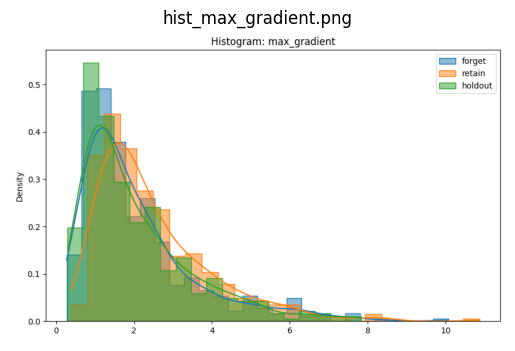

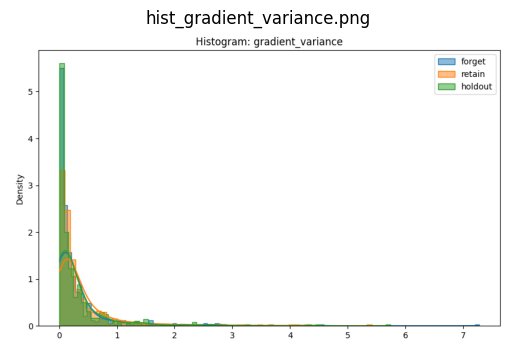

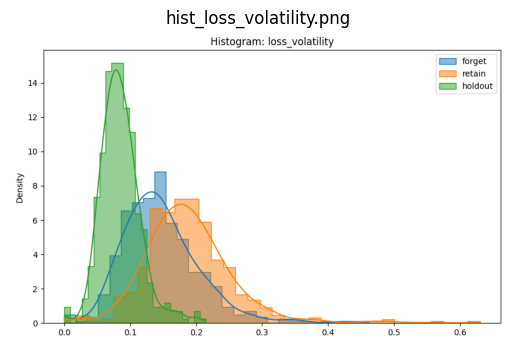

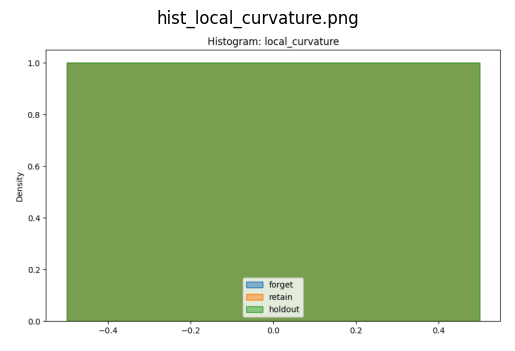

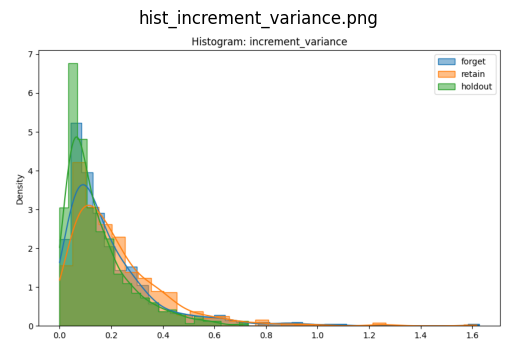

In [ ]:
eval_with_ILL.show_plots(plots, ['hist'])

In [ ]:
norm_forget_tensor, norm_retain_tensor, norm_holdout_tensor = eval_with_ILL.normalize_features(forget_tensor, retain_tensor, holdout_tensor)

In [ ]:
# use the function
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

# Get feature labels from the features dictionary
features_labels = features_dict['forget']['features_names']

# Train predictors using normalized tensors
results, feature_importance_results = eval_with_ILL.train_predictors(
    retain_t=norm_retain_tensor,
    holdout_t=norm_holdout_tensor,
    features_labels=features_labels,
    forget_t=norm_forget_tensor
)

print("\n=== Classification Results ===")
for metric in ['accuracy', 'f1', 'roc_auc']:
    print(f"Logistic Regression {metric.upper()}: {results['multi_class']['logistic'][metric]:.3f}")
    print(f"Random Forest {metric.upper()}: {results['multi_class']['random_forest'][metric]:.3f}")
    print()



=== Classification Results ===
Logistic Regression ACCURACY: 0.779
Random Forest ACCURACY: 0.742

Logistic Regression F1: 0.772
Random Forest F1: 0.740

Logistic Regression ROC_AUC: 0.892
Random Forest ROC_AUC: 0.890



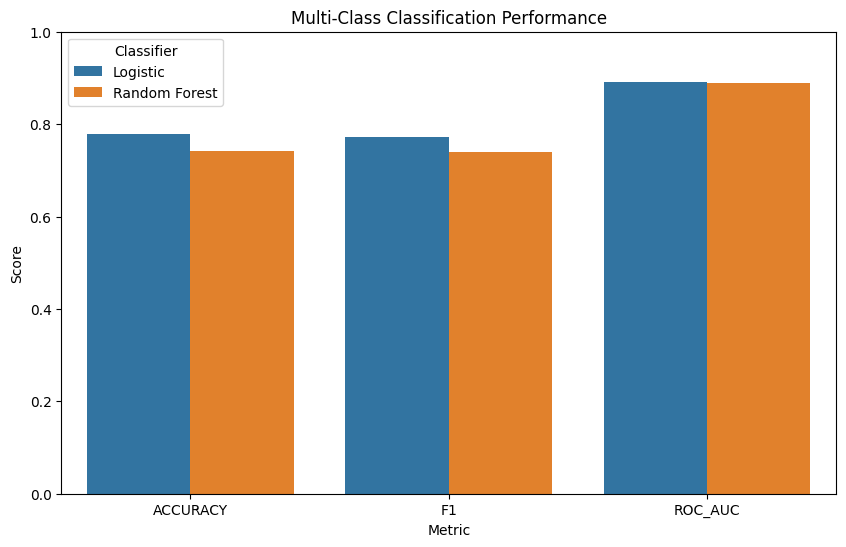

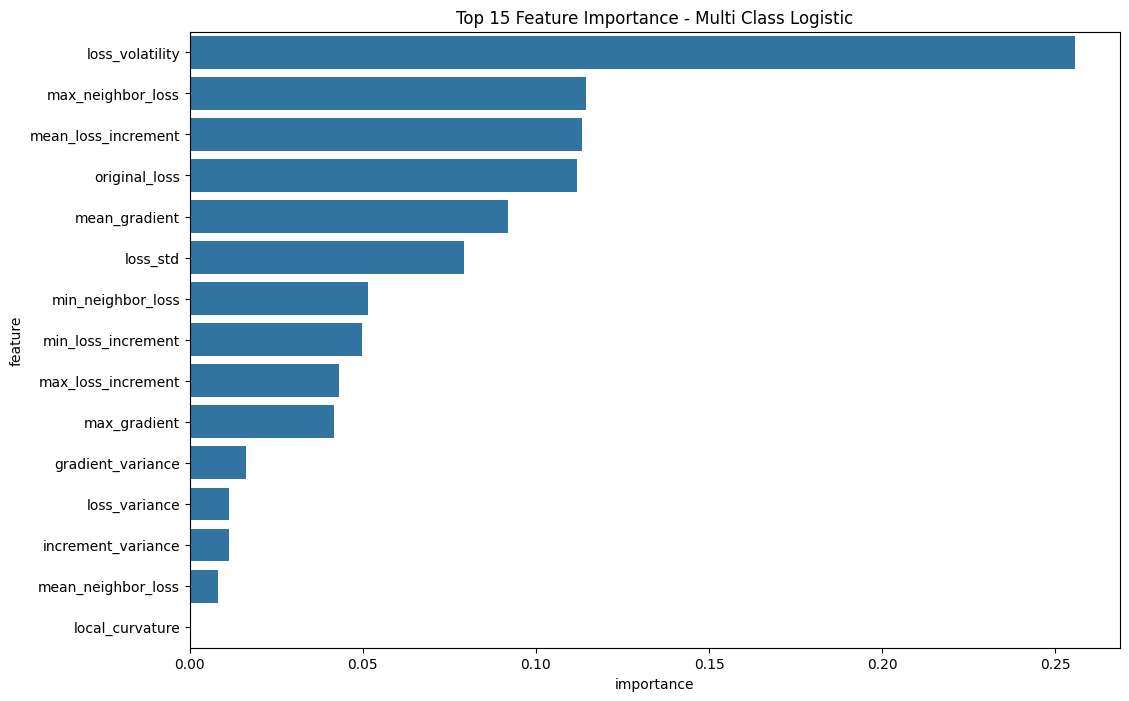

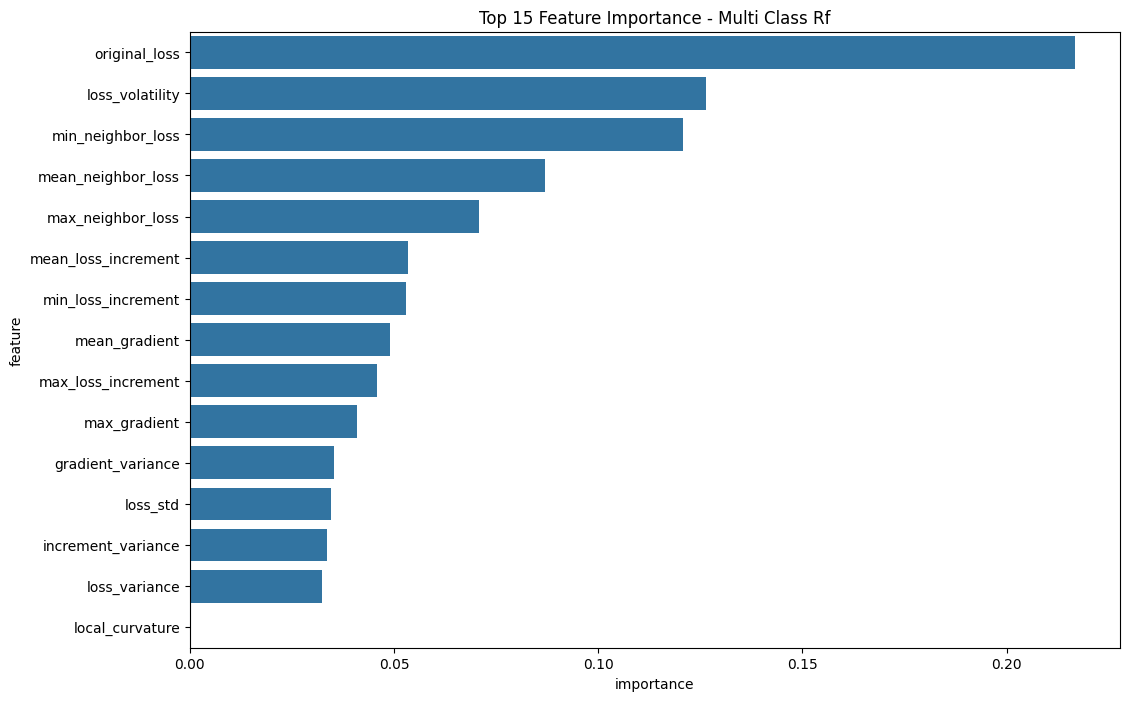

In [ ]:
# Create plots
classification_plots = eval_with_ILL.plot_classification_results(results, feature_importance_results)

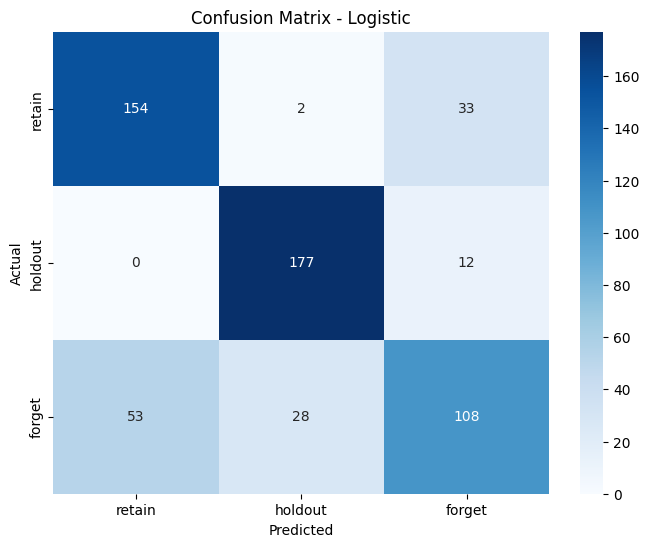

\n=== Classification Report - Logistic ===
              precision    recall  f1-score   support

      retain       0.74      0.81      0.78       189
     holdout       0.86      0.94      0.89       189
      forget       0.71      0.57      0.63       189

    accuracy                           0.77       567
   macro avg       0.77      0.77      0.77       567
weighted avg       0.77      0.77      0.77       567



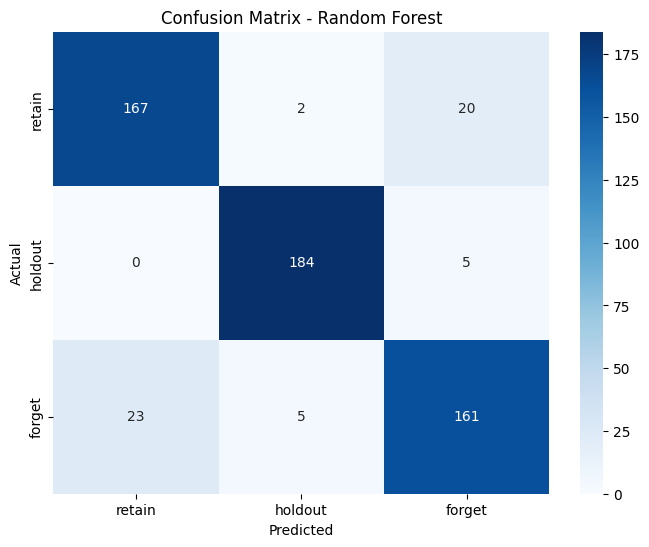

\n=== Classification Report - Random Forest ===
              precision    recall  f1-score   support

      retain       0.88      0.88      0.88       189
     holdout       0.96      0.97      0.97       189
      forget       0.87      0.85      0.86       189

    accuracy                           0.90       567
   macro avg       0.90      0.90      0.90       567
weighted avg       0.90      0.90      0.90       567



In [ ]:
# Plot confusion matrices
eval_with_ILL.plot_confusion_matrices(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

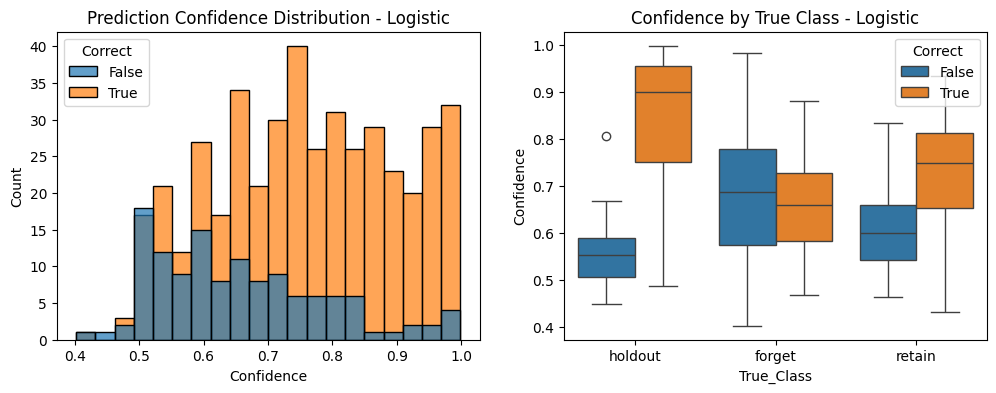

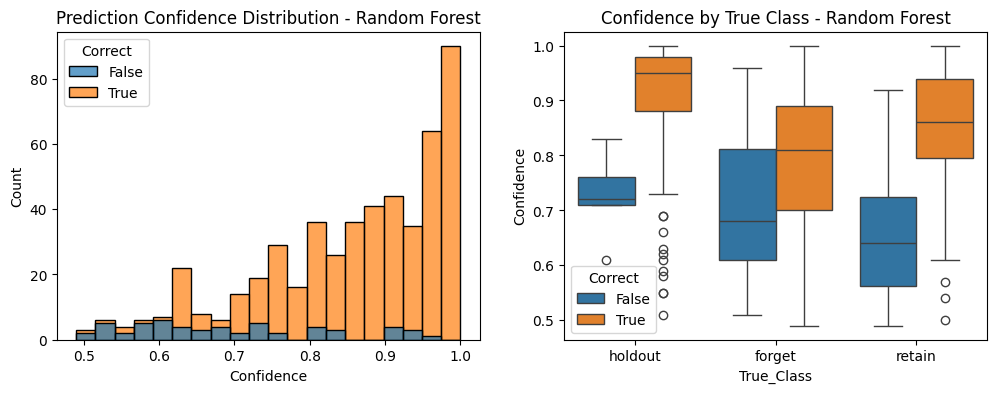


=== Summary ===
All plots have been generated and saved to the 'classification_plots' directory.
The analysis includes:
- Performance comparison between classifiers
- Feature importance for each classifier
- Confusion matrices
- Prediction confidence analysis
- Feature importance comparison between classifiers


In [ ]:
# Run confidence analysis
eval_with_ILL.analyze_prediction_confidence(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

print("\n=== Summary ===")
print("All plots have been generated and saved to the 'classification_plots' directory.")
print("The analysis includes:")
print("- Performance comparison between classifiers")
print("- Feature importance for each classifier")
print("- Confusion matrices")
print("- Prediction confidence analysis")
print("- Feature importance comparison between classifiers")


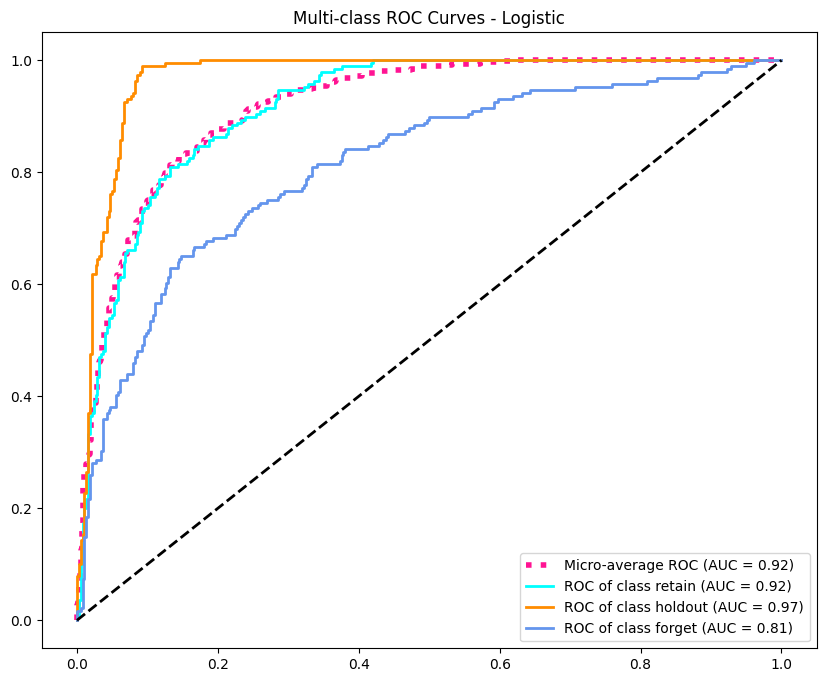

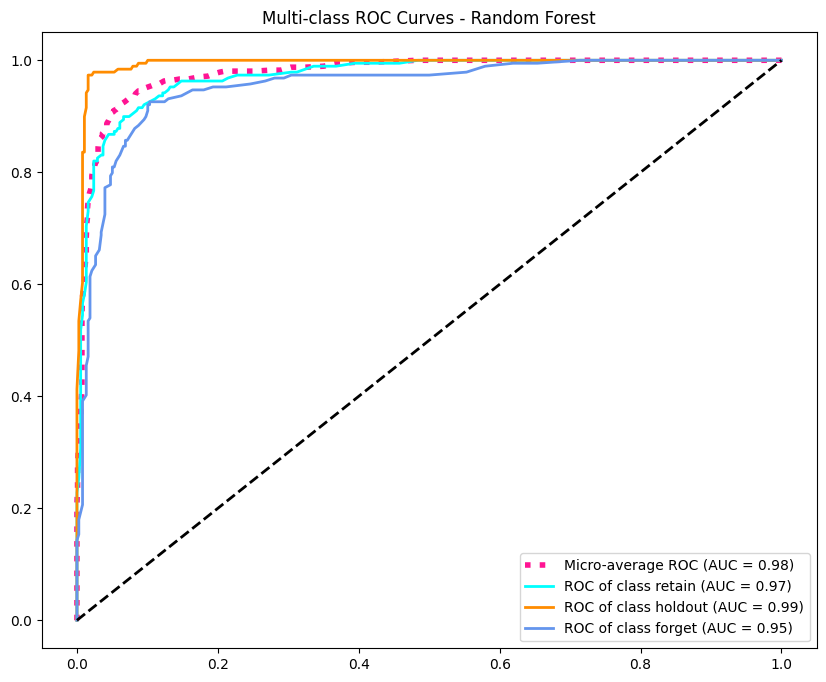

In [ ]:
 # Generate ROC curves
eval_with_ILL.plot_multiclass_roc_curves(results, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)


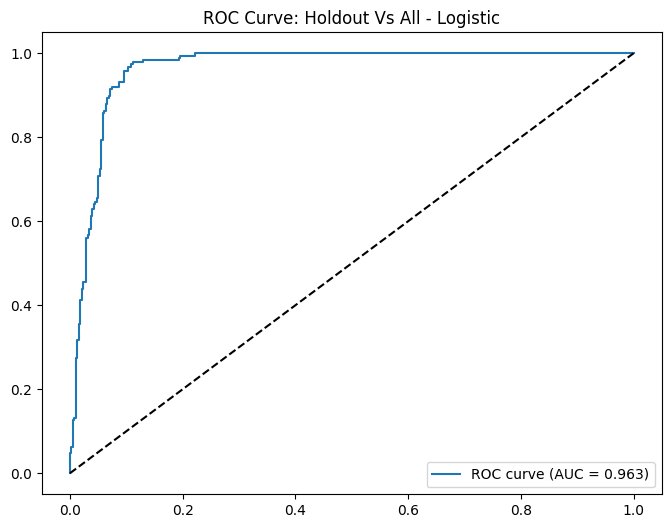

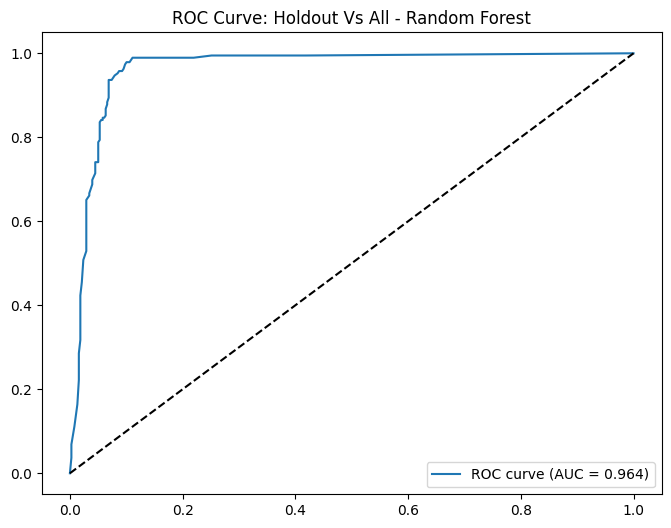

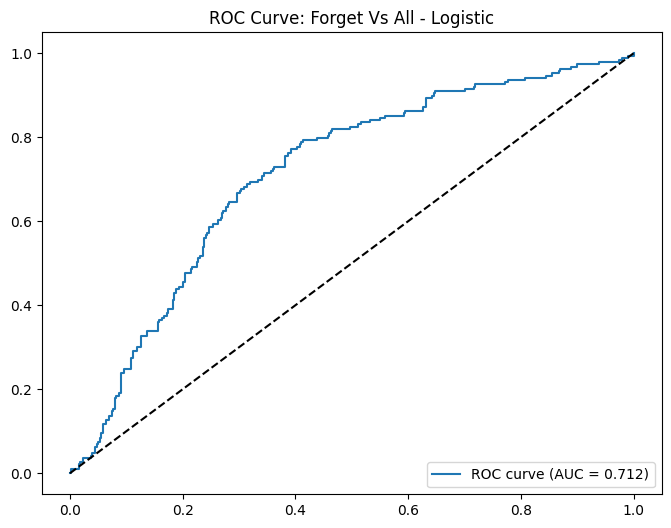

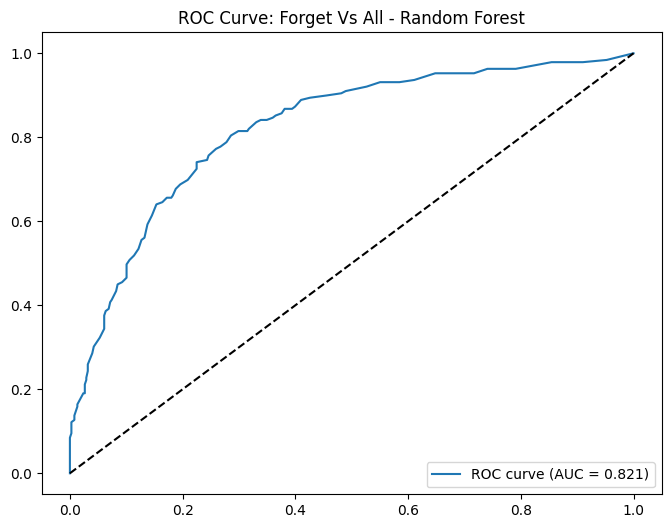

In [ ]:
# Run binary comparisons
binary_results, binary_feature_importance = eval_with_ILL.train_binary_comparisons(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)


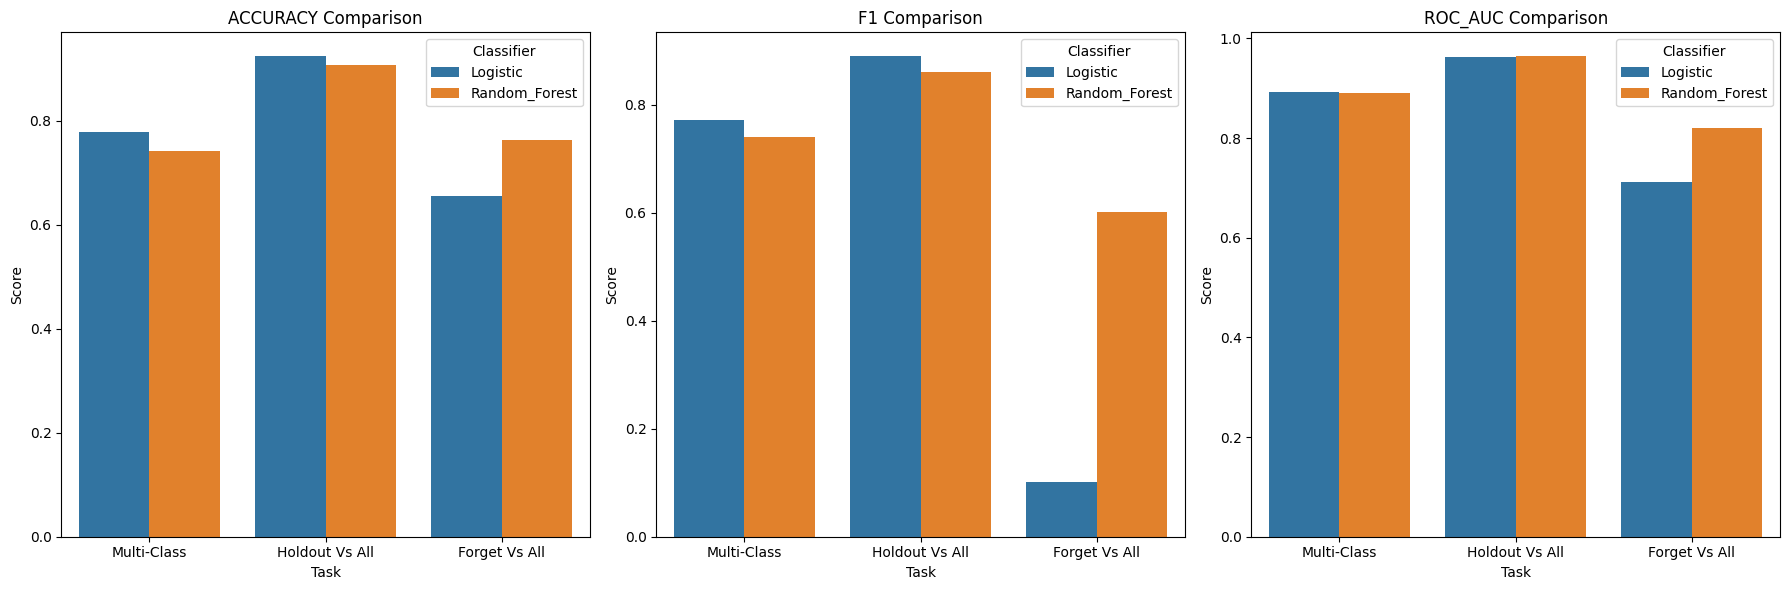

In [ ]:
# Comprehensive Analysis and Summary
plots = eval_with_ILL.create_comprehensive_summary(results, binary_results, feature_importance_results, binary_feature_importance)


# Input Loss Landscape (ILL) Discriminative Analysis

This section provides specialized methods to analyze and distinguish between **forget**, **retain**, and **holdout** datasets using Input Loss Landscape features. 

## ILL Features Used:
- **Loss-based**: `original_loss`, `mean_neighbor_loss`, `max_neighbor_loss`, `min_neighbor_loss`
- **Variance-based**: `loss_variance`, `loss_std`, `increment_variance`
- **Gradient-based**: `mean_gradient`, `max_gradient`, `gradient_variance`
- **Landscape properties**: `loss_volatility`, `local_curvature`
- **Increment-based**: `mean_loss_increment`, `max_loss_increment`, `min_loss_increment`
- **Embeddings**: Sentence embeddings for semantic analysis

The goal is to identify which ILL features are most discriminative for distinguishing between the three dataset types.

In [ ]:
# Additional imports for comprehensive landscape analysis
from scipy.stats import wasserstein_distance, ks_2samp, entropy, skew, kurtosis
from scipy.spatial.distance import jensenshannon, pdist, squareform
from sklearn.manifold import TSNE, Isomap
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
import seaborn as sns

# Try to import UMAP, install if not available
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    print("UMAP not available. Install with: pip install umap-learn")
    UMAP_AVAILABLE = False

In [ ]:
# Compute statistical distances
print("Computing statistical distances between datasets...")
stat_distances = eval_with_ILL.compute_statistical_distances(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels)

Computing statistical distances between datasets...


# EXP: plot_statistical_distances
The plot_statistical_distances function generates heatmaps to visualize statistical distances—Wasserstein Distance, KS Statistic, and Jensen-Shannon Divergence—across features for dataset comparisons (retain, holdout, forget). Each heatmap shows how feature distributions differ between dataset pairs, with rows representing features and columns representing comparisons. Higher values indicate greater dissimilarity, helping identify features or dataset pairs with significant distributional differences. The heatmaps are annotated with precise values for clarity and saved as statistical_distances_heatmap.png.

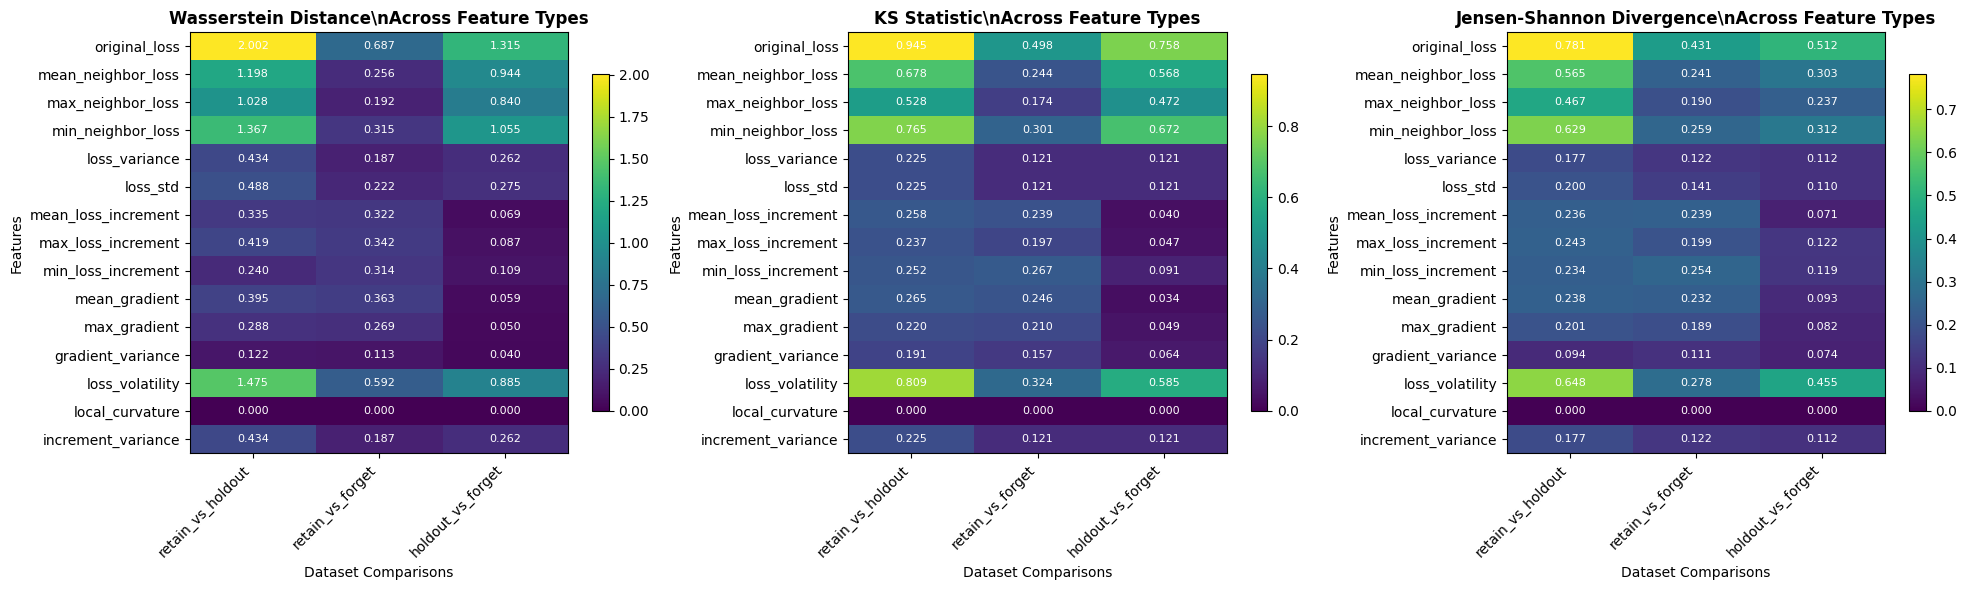

In [ ]:
eval_with_ILL.plot_statistical_distances(stat_distances, features_labels)

# EXP: compare_manifold_structures
The compare_manifold_structures function visualizes the separability of datasets (retain, holdout, forget) by projecting their high-dimensional features into a 2D space using dimensionality reduction techniques such as PCA, t-SNE, Isomap, and optionally UMAP. Each plot represents the datasets as clusters of points, with colors indicating the dataset type. Well-separated clusters suggest distinct dataset characteristics, while overlapping clusters indicate shared properties. These visualizations help assess the structural differences between datasets and evaluate their separability in the feature space. The plots are saved as manifold_comparisons.png.

Analyzing manifold structures...
Computing PCA embedding...
Computing TSNE embedding...
Computing Isomap embedding...
Computing Isomap embedding...
Computing UMAP embedding...
Computing UMAP embedding...


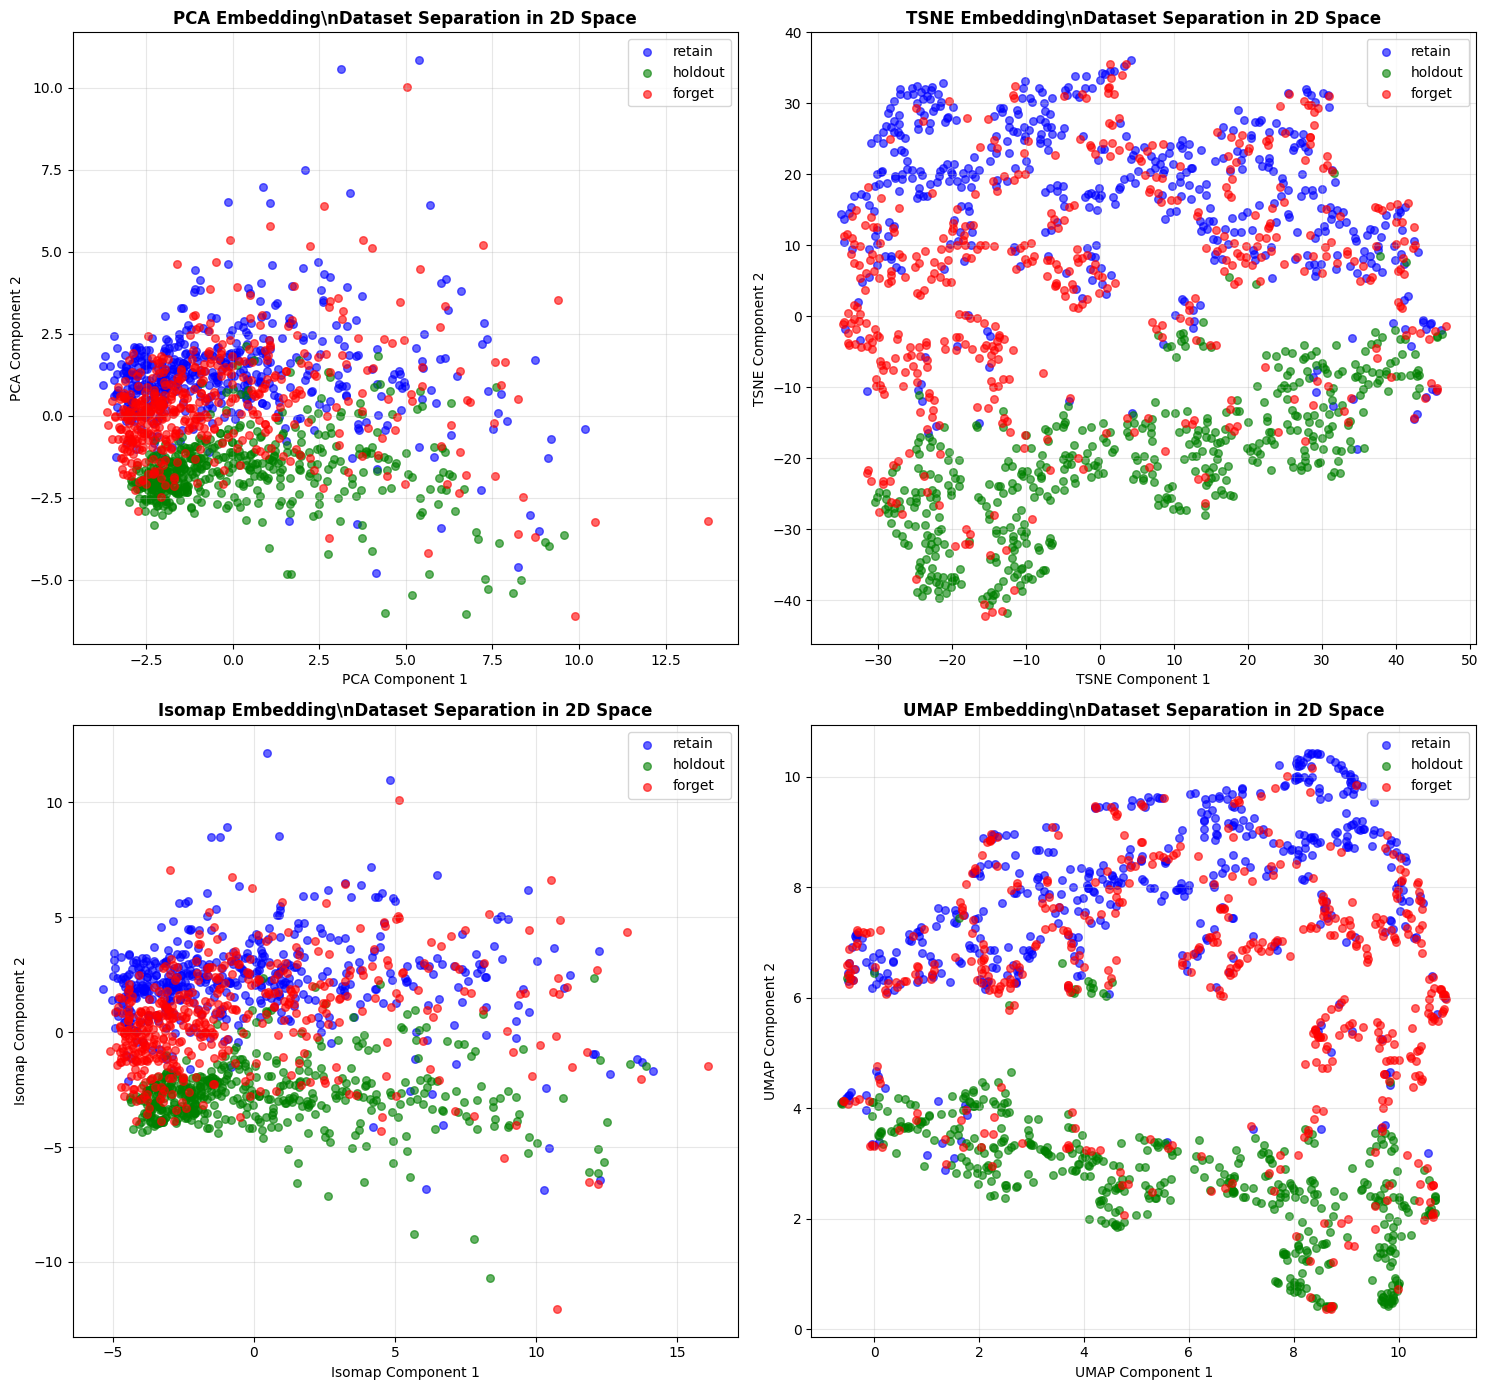

In [ ]:
# Run manifold analysis
print("Analyzing manifold structures...")
manifold_results = eval_with_ILL.compare_manifold_structures(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

Analyzing clustering patterns...


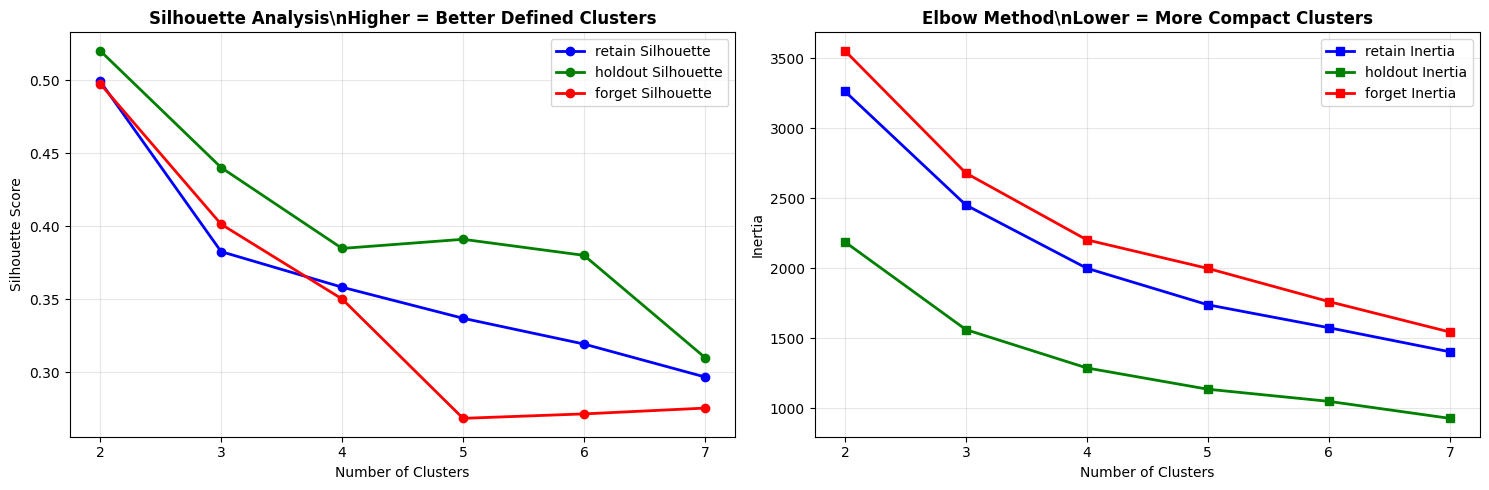

In [ ]:
# Run clustering analysis
print("Analyzing clustering patterns...")
clustering_results = eval_with_ILL.analyze_clustering_patterns(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

In [ ]:
# Compute topology analysis
print("Analyzing landscape topology...")
topology_results = eval_with_ILL.analyze_landscape_topology(features_dict)

Analyzing landscape topology...


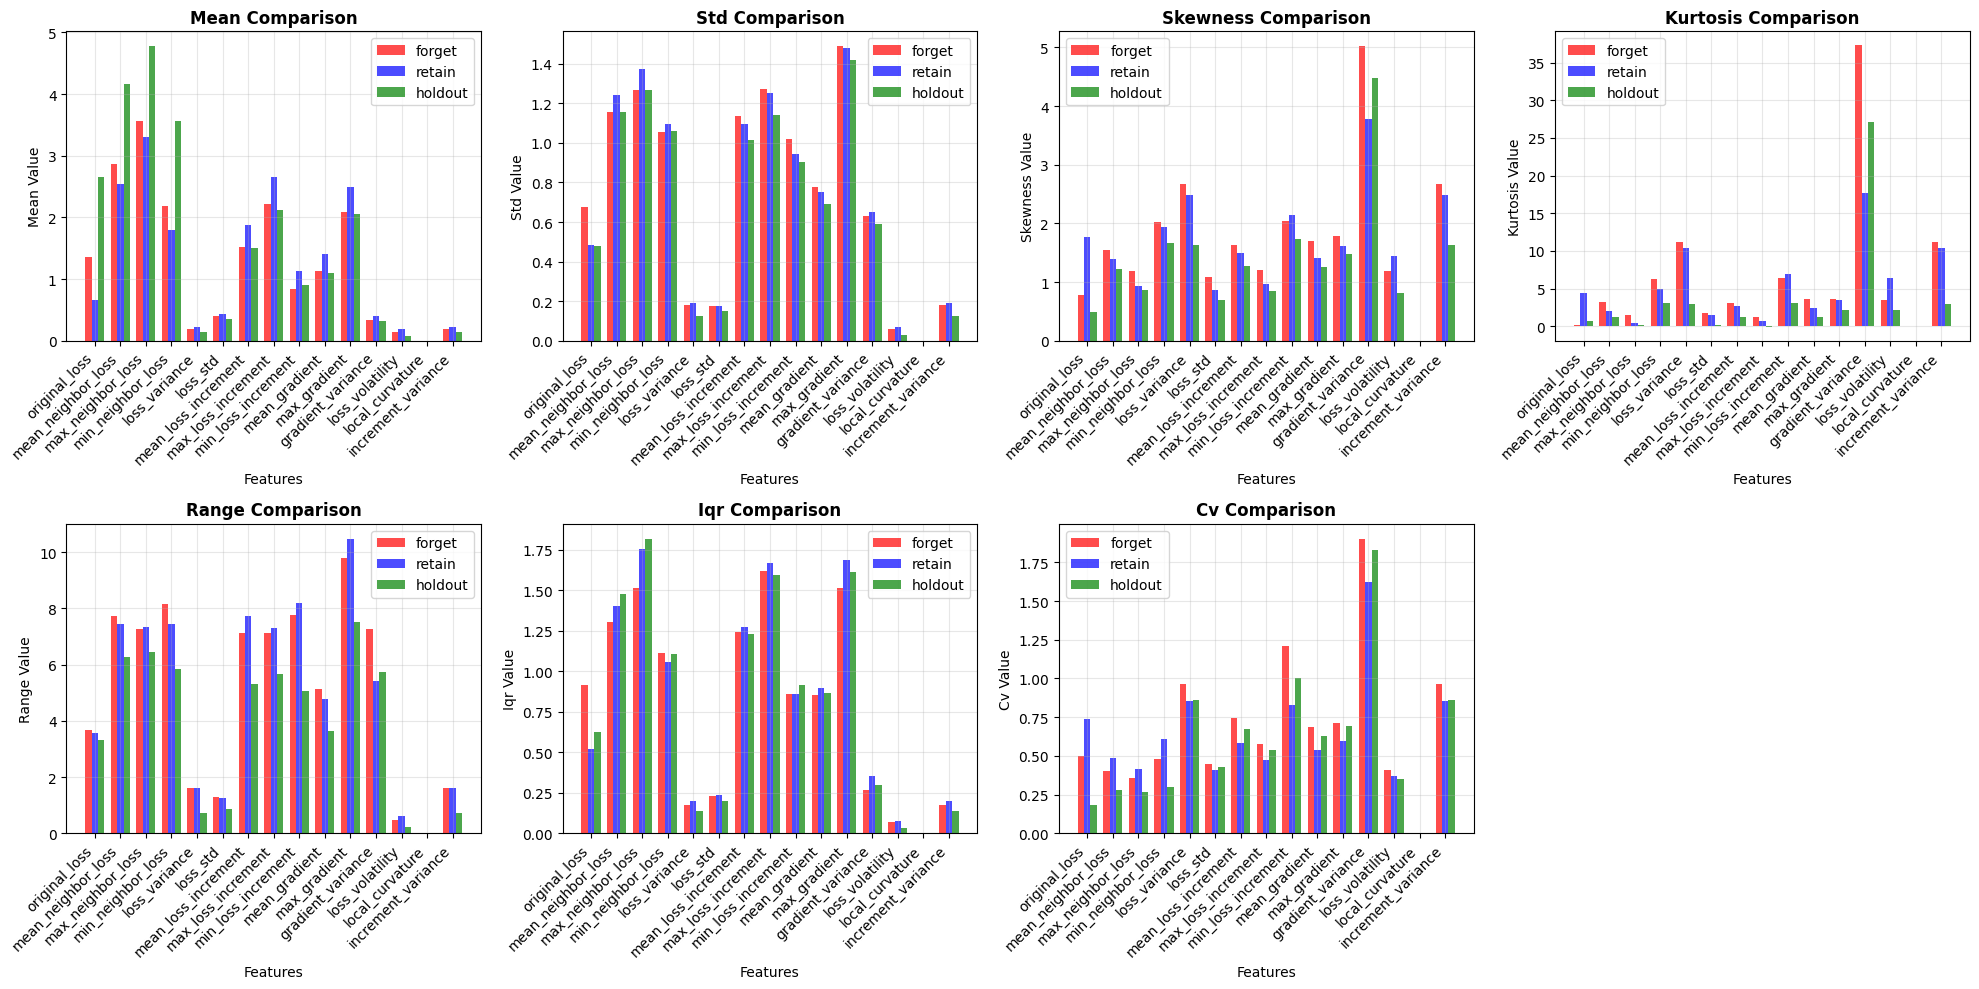

In [ ]:
# Plot topology comparison
eval_with_ILL.plot_topology_comparison(topology_results, features_labels)

In [ ]:
# Compute smoothness analysis
print("Analyzing landscape smoothness...")
smoothness_results = eval_with_ILL.analyze_landscape_smoothness(features_dict)

Analyzing landscape smoothness...


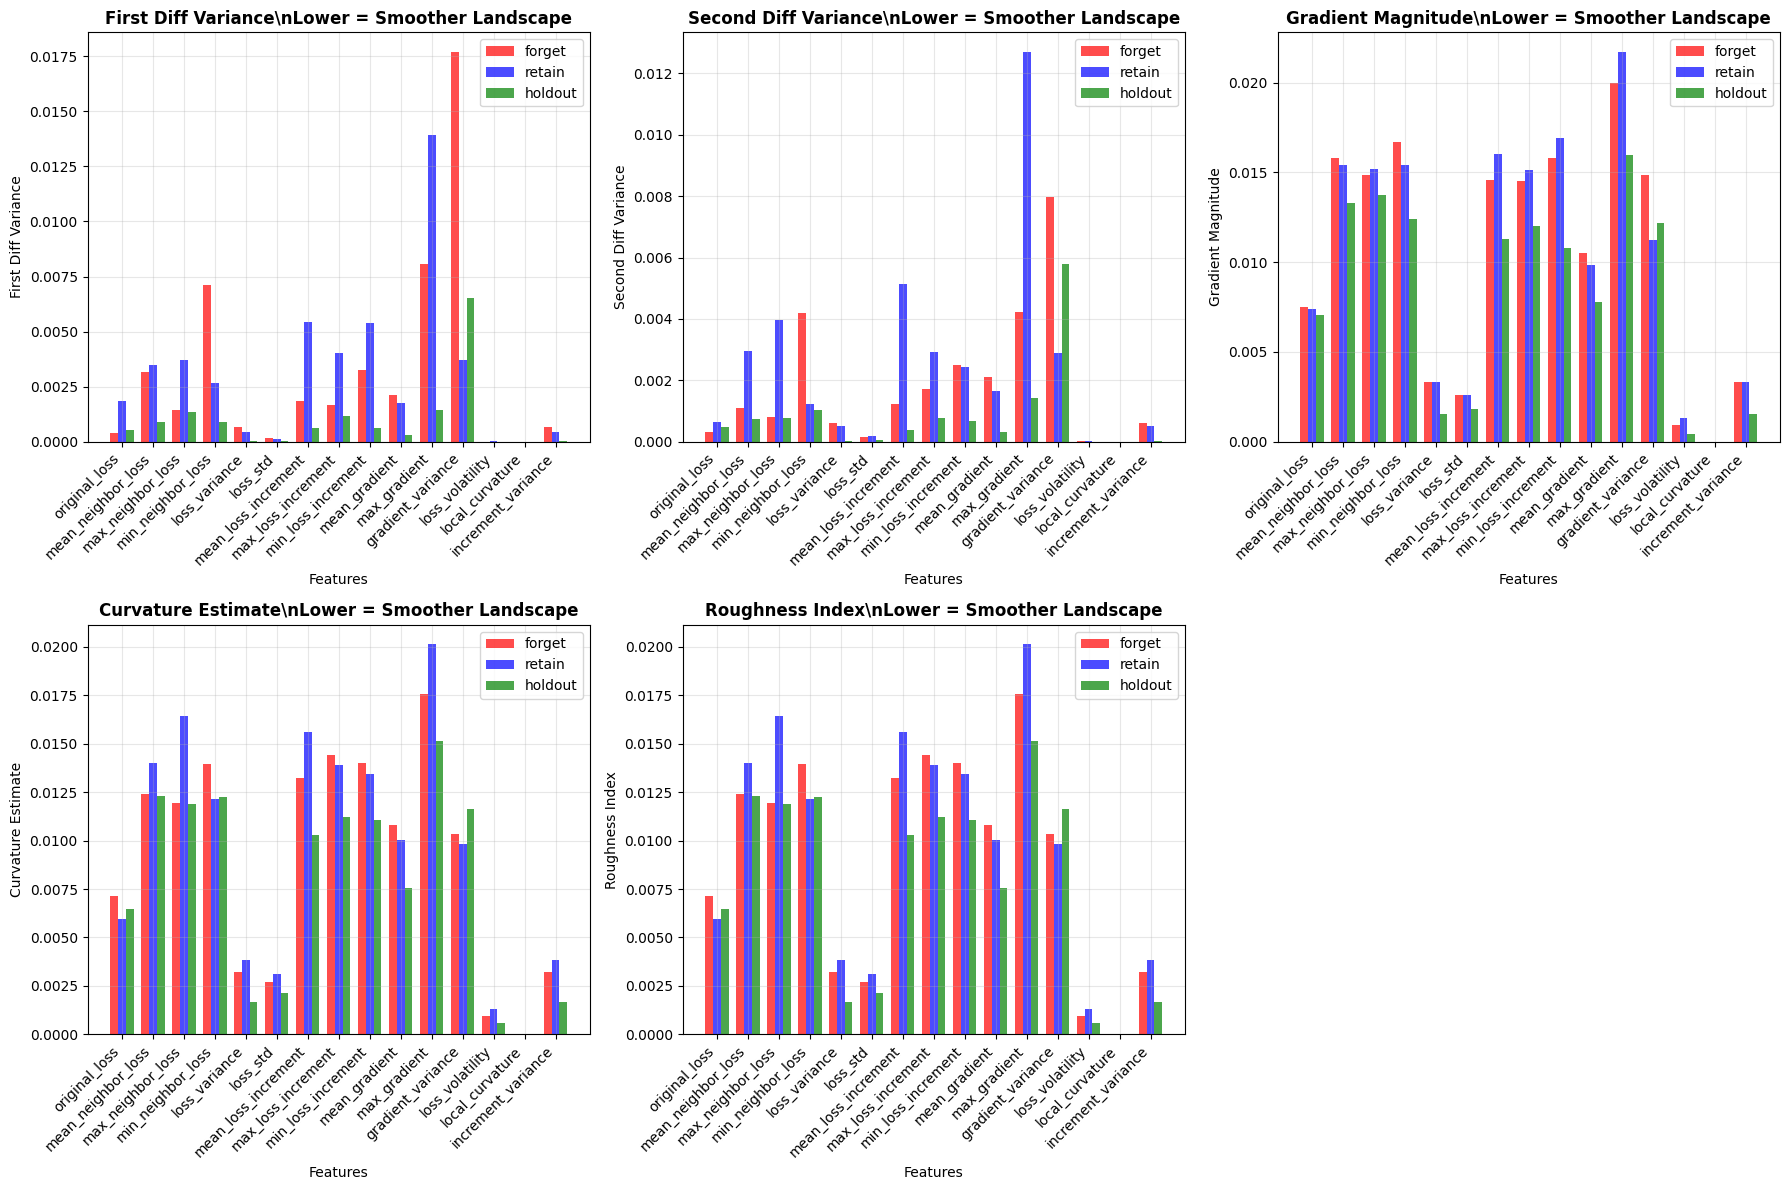

In [ ]:
# Plot smoothness comparison
eval_with_ILL.plot_smoothness_comparison(smoothness_results, features_labels)

In [ ]:
# Run transfer analysis
print("Analyzing prediction transfer...")
transfer_results = eval_with_ILL.analyze_prediction_transfer( , norm_holdout_tensor, norm_forget_tensor)

Analyzing prediction transfer...


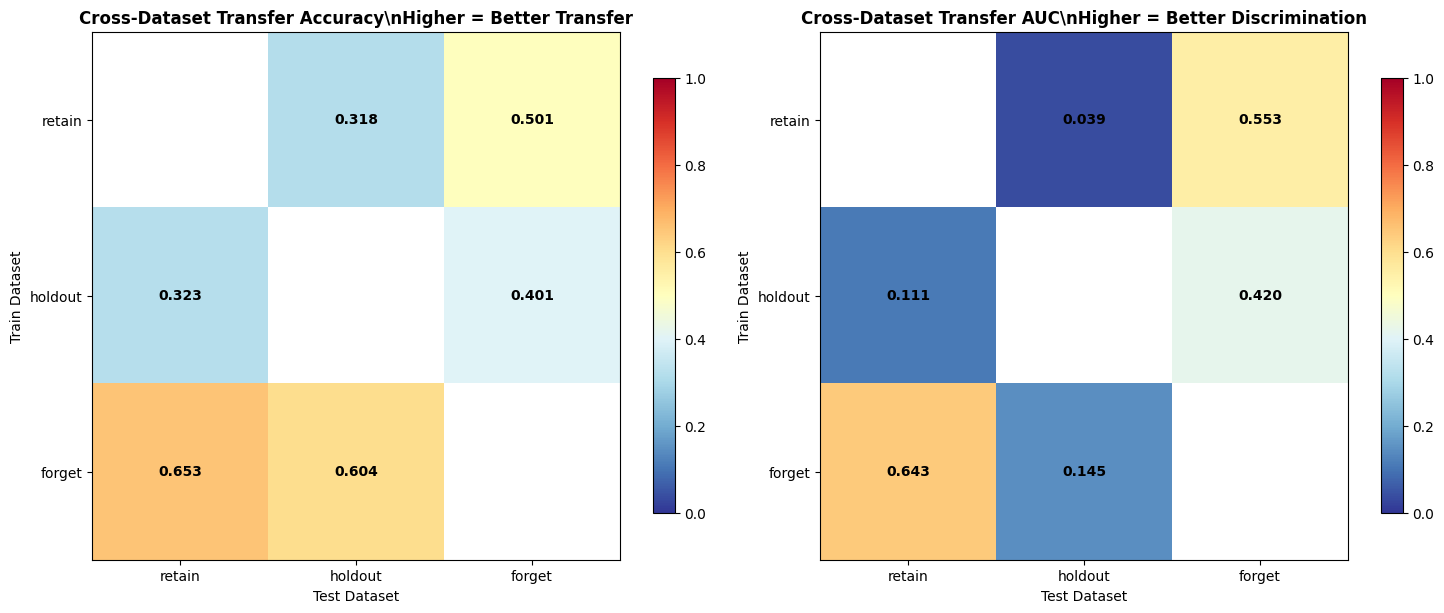

In [ ]:
# Plot transfer results
eval_with_ILL.plot_transfer_results(transfer_results)

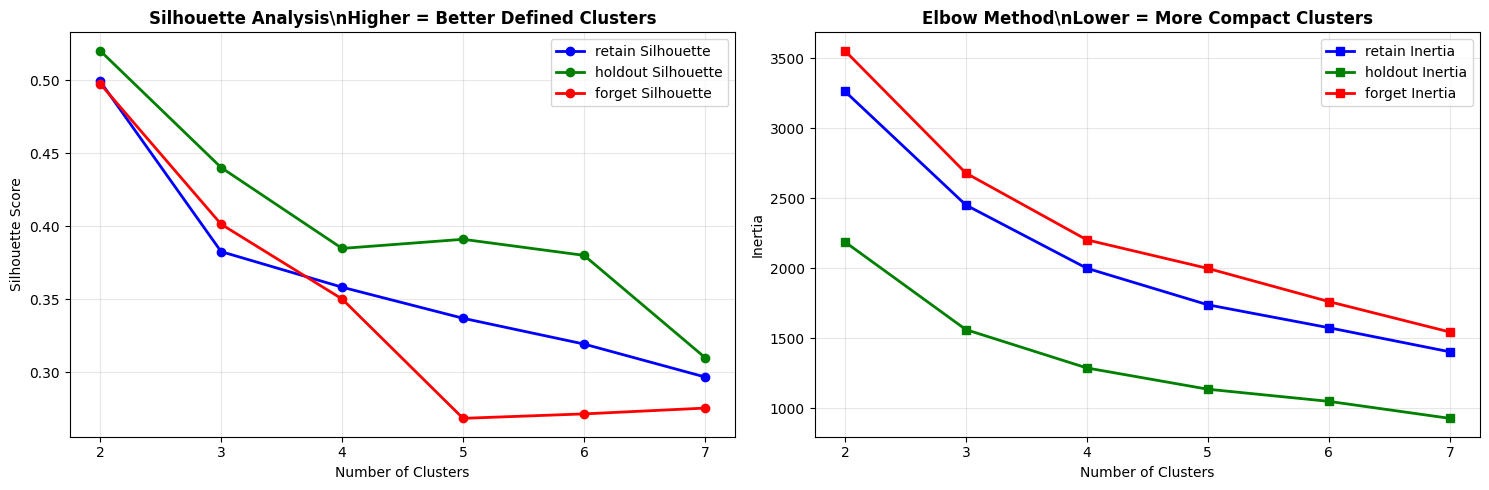

COMPREHENSIVE LANDSCAPE COMPARISON SUMMARY
\n1. STATISTICAL DISTANCES SUMMARY:
----------------------------------------
\nRETAIN_VS_HOLDOUT:
  Average Wasserstein Distance: 0.6816
  Average KS Statistic: 0.3881
  Average Jensen-Shannon Divergence: 0.3260
\nRETAIN_VS_FORGET:
  Average Wasserstein Distance: 0.2907
  Average KS Statistic: 0.2145
  Average Jensen-Shannon Divergence: 0.2005
\nHOLDOUT_VS_FORGET:
  Average Wasserstein Distance: 0.4168
  Average KS Statistic: 0.2494
  Average Jensen-Shannon Divergence: 0.1810
\n2. TOPOLOGICAL PROPERTIES SUMMARY:
----------------------------------------
\nFORGET:
  Original_Loss:
    mean: 1.3528
    std: 0.6743
    skewness: 0.7722
    kurtosis: 0.1744
    range: 3.6889
    iqr: 0.9160
    cv: 0.4985
  Mean_Neighbor_Loss:
    mean: 2.8728
    std: 1.1533
    skewness: 1.5561
    kurtosis: 3.2033
    range: 7.7292
    iqr: 1.3020
    cv: 0.4015
  Max_Neighbor_Loss:
    mean: 3.5681
    std: 1.2670
    skewness: 1.1858
    kurtosis: 1.4287
    r

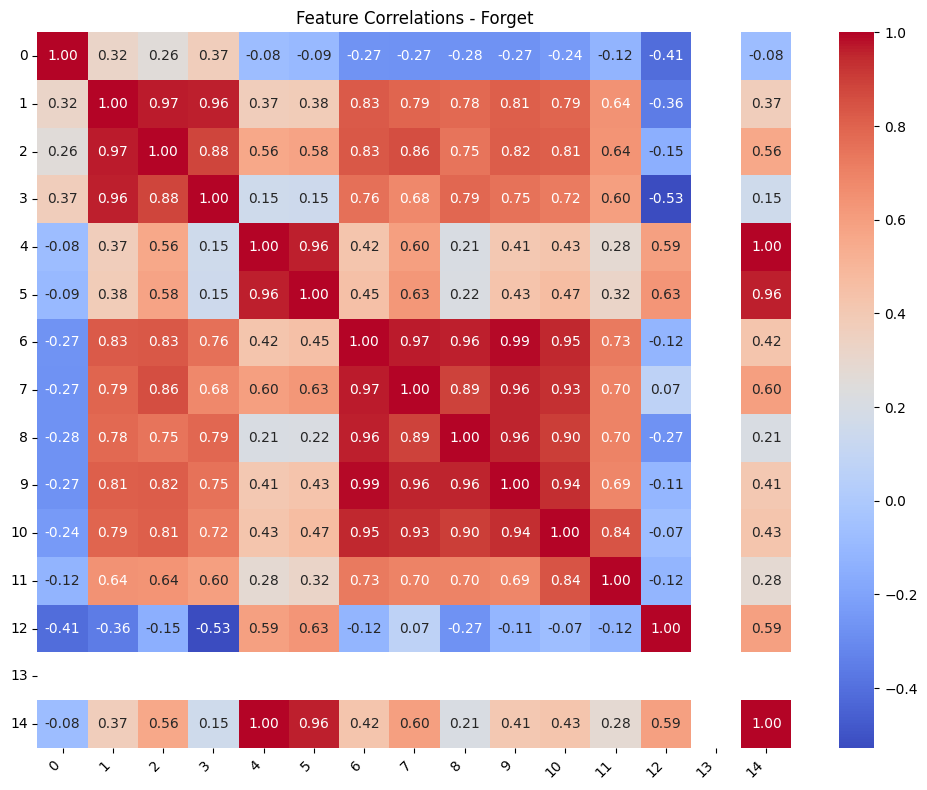

\nRETAIN:
  Original_Loss:
    mean: 0.6600
    std: 0.4851
    skewness: 1.7697
    kurtosis: 4.3775
    range: 3.5682
    iqr: 0.5235
    cv: 0.7350
  Mean_Neighbor_Loss:
    mean: 2.5378
    std: 1.2403
    skewness: 1.3960
    kurtosis: 1.9635
    range: 7.4435
    iqr: 1.4008
    cv: 0.4887
  Max_Neighbor_Loss:
    mean: 3.3103
    std: 1.3754
    skewness: 0.9373
    kurtosis: 0.3930
    range: 7.3435
    iqr: 1.7588
    cv: 0.4155
  Min_Neighbor_Loss:
    mean: 1.7975
    std: 1.0951
    skewness: 1.9379
    kurtosis: 4.8691
    range: 7.4480
    iqr: 1.0565
    cv: 0.6092
  Loss_Variance:
    mean: 0.2201
    std: 0.1887
    skewness: 2.4887
    kurtosis: 10.3589
    range: 1.6174
    iqr: 0.1986
    cv: 0.8571
  Loss_Std:
    mean: 0.4344
    std: 0.1772
    skewness: 0.8722
    kurtosis: 1.4961
    range: 1.2718
    iqr: 0.2370
    cv: 0.4080
  Mean_Loss_Increment:
    mean: 1.8778
    std: 1.0969
    skewness: 1.4922
    kurtosis: 2.6736
    range: 7.7308
    iqr: 1.2734
   

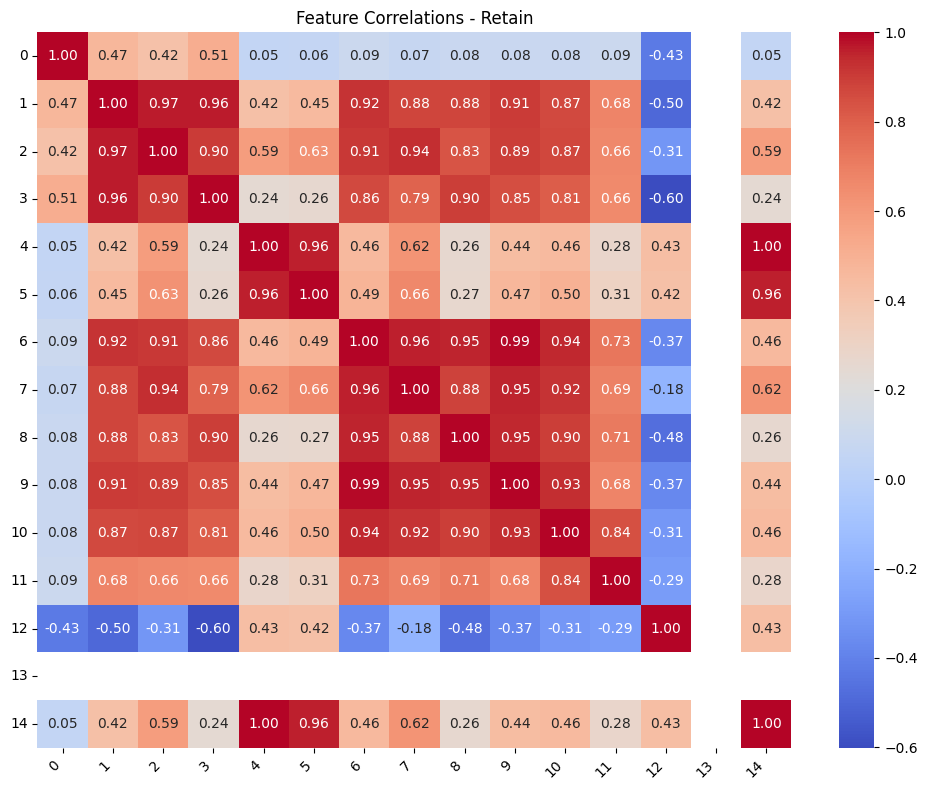

\nHOLDOUT:
  Original_Loss:
    mean: 2.6639
    std: 0.4811
    skewness: 0.4914
    kurtosis: 0.6196
    range: 3.3125
    iqr: 0.6266
    cv: 0.1806
  Mean_Neighbor_Loss:
    mean: 4.1609
    std: 1.1555
    skewness: 1.2291
    kurtosis: 1.2781
    range: 6.2709
    iqr: 1.4762
    cv: 0.2777
  Max_Neighbor_Loss:
    mean: 4.7796
    std: 1.2662
    skewness: 0.8690
    kurtosis: 0.0885
    range: 6.4630
    iqr: 1.8202
    cv: 0.2649
  Min_Neighbor_Loss:
    mean: 3.5634
    std: 1.0580
    skewness: 1.6588
    kurtosis: 3.0777
    range: 5.8544
    iqr: 1.1077
    cv: 0.2969
  Loss_Variance:
    mean: 0.1454
    std: 0.1247
    skewness: 1.6411
    kurtosis: 2.9277
    range: 0.7303
    iqr: 0.1372
    cv: 0.8580
  Loss_Std:
    mean: 0.3503
    std: 0.1506
    skewness: 0.6900
    kurtosis: 0.1824
    range: 0.8546
    iqr: 0.2023
    cv: 0.4300
  Mean_Loss_Increment:
    mean: 1.4970
    std: 1.0129
    skewness: 1.2684
    kurtosis: 1.1692
    range: 5.3045
    iqr: 1.2329
   

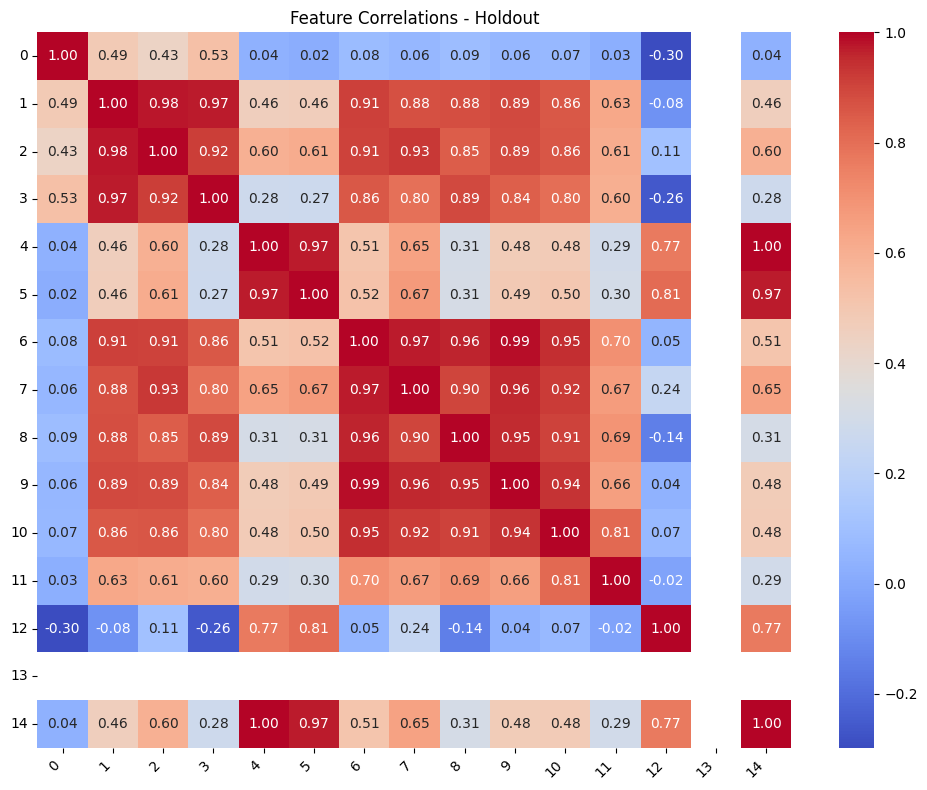

\n3. CLUSTERING PATTERNS SUMMARY:
----------------------------------------
  Retain: Best Silhouette = 0.4993, Best Inertia = 1401.6299
  Holdout: Best Silhouette = 0.5202, Best Inertia = 926.1702
  Forget: Best Silhouette = 0.4977, Best Inertia = 1543.2220
\n4. SMOOTHNESS ANALYSIS SUMMARY:
----------------------------------------
  Forget:
    First Diff Var: 0.0032
    Second Diff Var: 0.0018
    Gradient Magnitude: 0.0103
    Curvature Estimate: 0.0091
    Roughness Index: 0.0091
  Retain:
    First Diff Var: 0.0031
    Second Diff Var: 0.0025
    Gradient Magnitude: 0.0103
    Curvature Estimate: 0.0096
    Roughness Index: 0.0096
  Holdout:
    First Diff Var: 0.0010
    Second Diff Var: 0.0008
    Gradient Magnitude: 0.0081
    Curvature Estimate: 0.0077
    Roughness Index: 0.0077
\n5. TRANSFER LEARNING RESULTS SUMMARY:
----------------------------------------
  train_retain_test_holdout: Accuracy = 0.3178, AUC = 0.0387
  train_retain_test_forget: Accuracy = 0.5014, AUC = 0.5527

In [ ]:
# Generate comprehensive summary
clustering_results = eval_with_ILL.analyze_clustering_patterns(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)
eval_with_ILL.create_landscape_summary_report(stat_distances, topology_results, smoothness_results, transfer_results, clustering_results)

In [ ]:
# Final comprehensive comparison - Run all methods together
print("Running comprehensive landscape analysis...")
print("This will generate multiple comparison plots and a summary report.")

# Create a summary of all results
comprehensive_results = {
    'statistical_distances': stat_distances,
    'manifold_results': manifold_results,
    'clustering_results': clustering_results,
    'topology_results': topology_results,
    'smoothness_results': smoothness_results,
    'transfer_results': transfer_results
}

# Save results for future reference
import pickle
results_file = f'{plots_base_dir}/comprehensive_landscape_results.pkl'
with open(results_file, 'wb') as f:
    pickle.dump(comprehensive_results, f)

print(f"\nAll results saved to: {results_file}")
print(f"All plots saved to: {plots_base_dir}/")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)
print("Generated plots:")
print("1. Statistical distances heatmap")
print("2. Manifold embeddings (PCA, t-SNE, UMAP, Isomap)")
print("3. Clustering analysis (Silhouette & Elbow)")
print("4. Topological properties comparison")
print("5. Landscape smoothness comparison")
print("6. Transfer learning performance")
print("="*60)

Running comprehensive landscape analysis...
This will generate multiple comparison plots and a summary report.

All results saved to: loss_landscape_plots/comprehensive_landscape_results.pkl
All plots saved to: loss_landscape_plots/

ANALYSIS COMPLETE!
Generated plots:
1. Statistical distances heatmap
2. Manifold embeddings (PCA, t-SNE, UMAP, Isomap)
3. Clustering analysis (Silhouette & Elbow)
4. Topological properties comparison
5. Landscape smoothness comparison
6. Transfer learning performance


In [ ]:
# ============================================================================
# SPECIALIZED ILL DISCRIMINATIVE ANALYSIS
# ============================================================================

# Run ILL discrimination analysis
print("Analyzing ILL feature discrimination...")
ill_discrimination = eval_with_ILL.analyze_ill_feature_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing ILL feature discrimination...
ILL FEATURE DISCRIMINATION ANALYSIS
Cross-validation accuracy: 0.736 (+/- 0.019)
Overall classification accuracy: 1.000

Top 5 Most Discriminative ILL Features:
1. original_loss: 0.2180
2. loss_volatility: 0.1226
3. min_neighbor_loss: 0.1181
4. mean_neighbor_loss: 0.0899
5. max_neighbor_loss: 0.0664
ILL FEATURE DISCRIMINATION ANALYSIS
Cross-validation accuracy: 0.736 (+/- 0.019)
Overall classification accuracy: 1.000

Top 5 Most Discriminative ILL Features:
1. original_loss: 0.2180
2. loss_volatility: 0.1226
3. min_neighbor_loss: 0.1181
4. mean_neighbor_loss: 0.0899
5. max_neighbor_loss: 0.0664


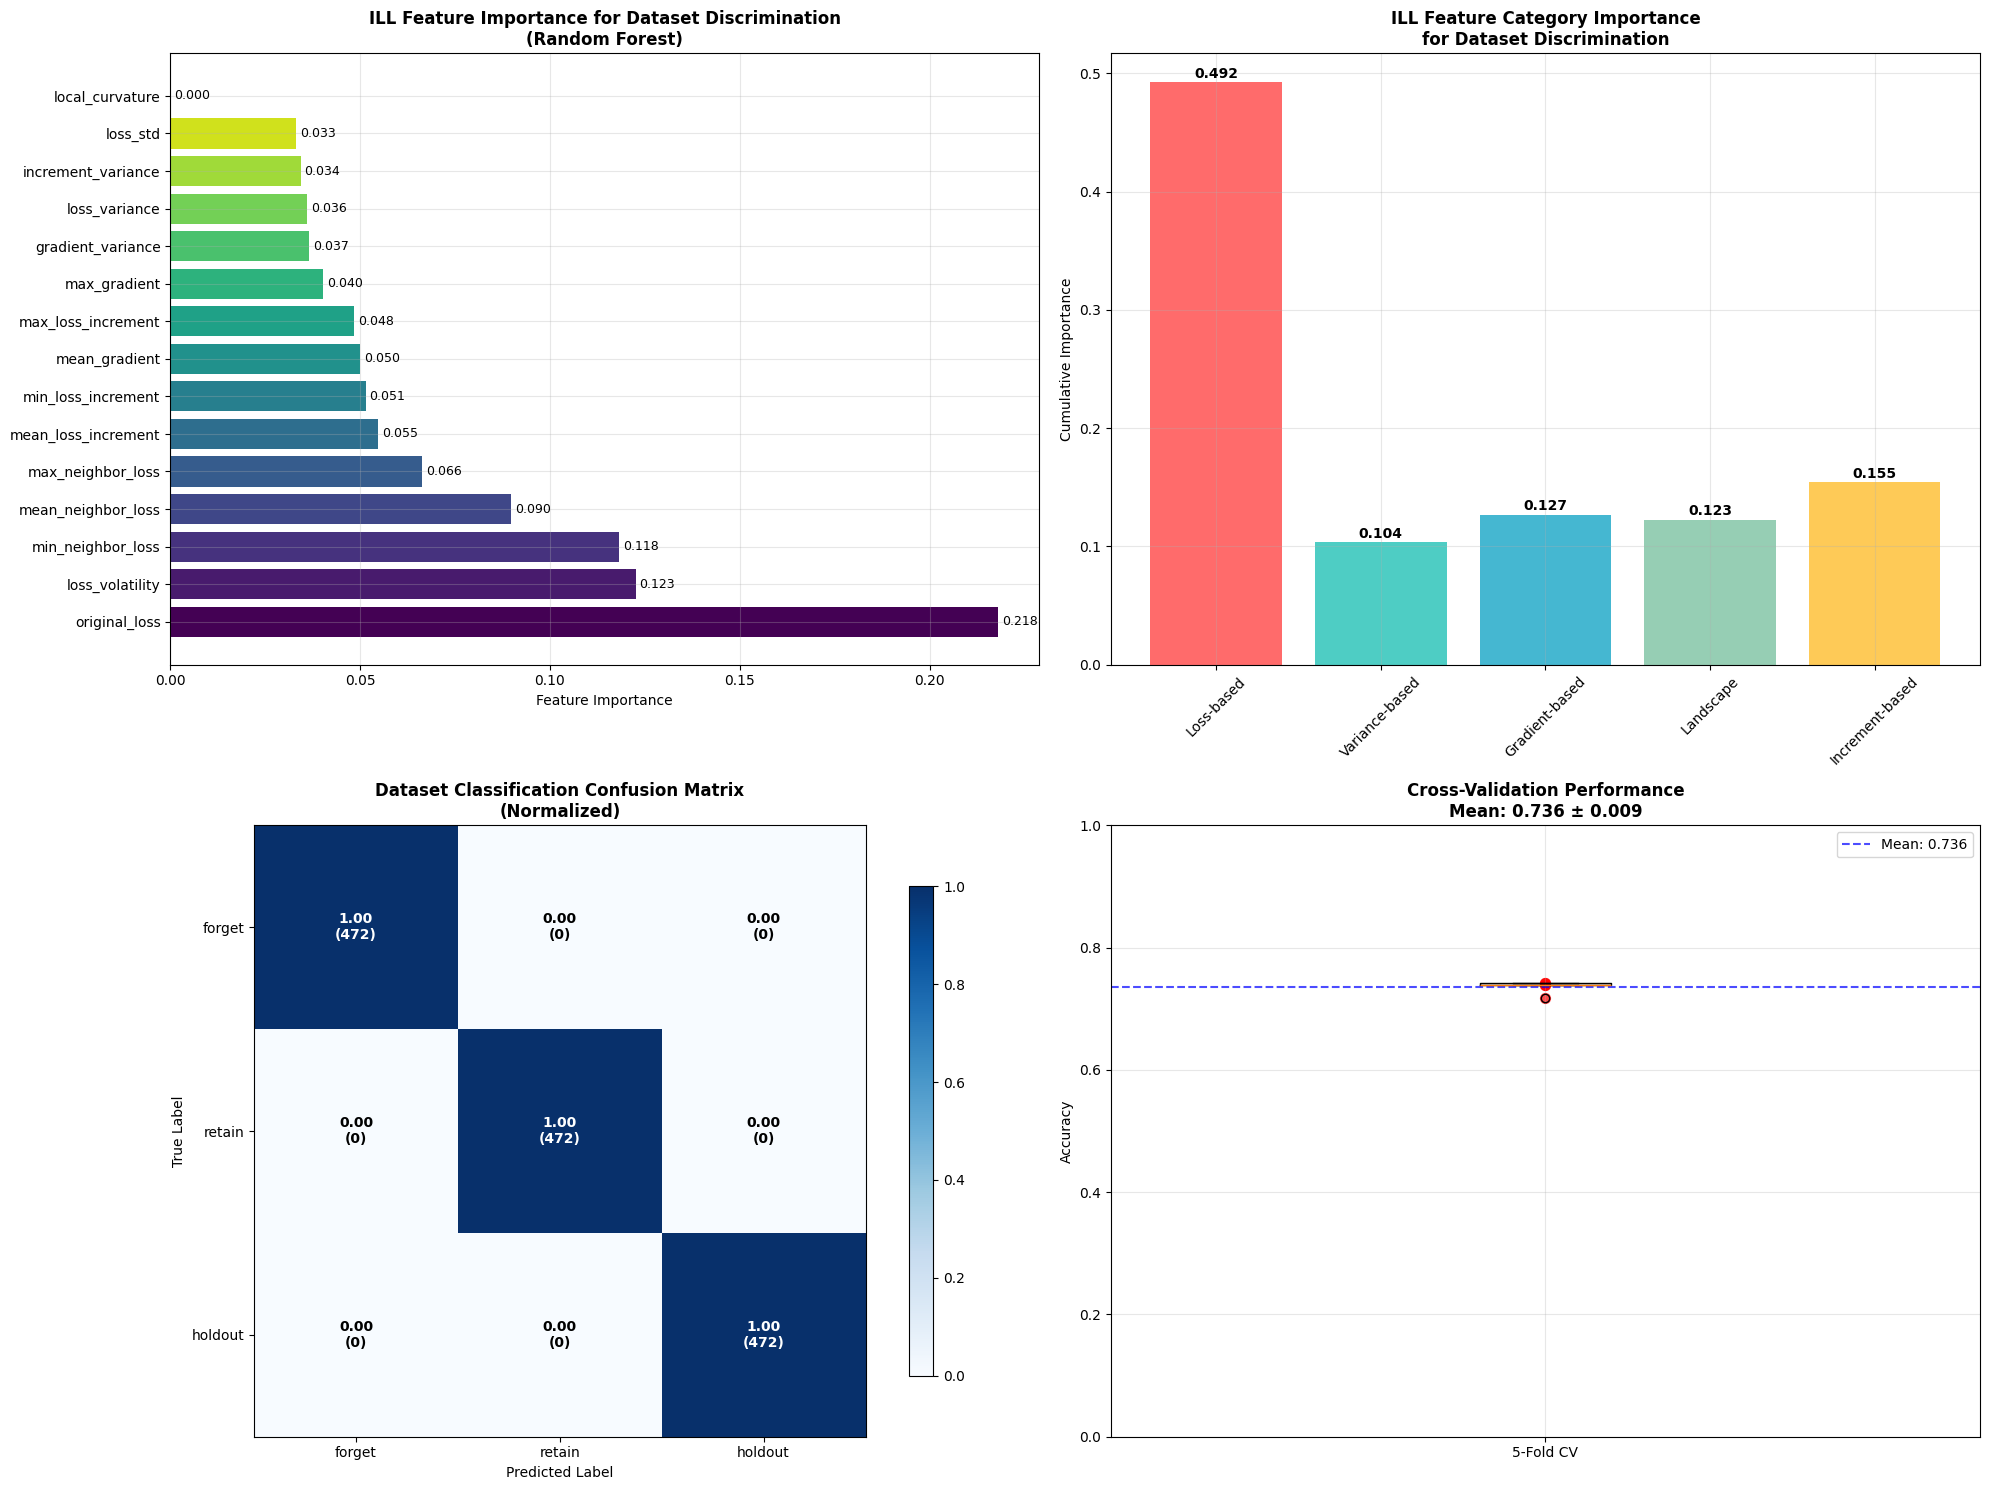

In [ ]:
# Plot ILL discrimination analysis
eval_with_ILL.plot_ill_discrimination_analysis(ill_discrimination, features_labels)

In [ ]:
# Run loss landscape topology discrimination analysis
print("Analyzing loss landscape topology for discrimination...")
topology_discrimination = eval_with_ILL.analyze_loss_landscape_topology_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing loss landscape topology for discrimination...
LOSS LANDSCAPE TOPOLOGY DISCRIMINATION ANALYSIS

LOSS FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 0.514
    Max effect size: 1.163
  forget vs holdout:
    Average effect size: 1.403
    Max effect size: 2.240
  retain vs holdout:
    Average effect size: 2.084
    Max effect size: 4.123

VARIANCE FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 0.175
    Max effect size: 0.208
  forget vs holdout:
    Average effect size: 0.284
    Max effect size: 0.286
  retain vs holdout:
    Average effect size: 0.483
    Max effect size: 0.514

GRADIENT FEATURES:
------------------------------
  forget vs retain:
    Average effect size: 0.234
    Max effect size: 0.345
  forget vs holdout:
    Average effect size: 0.031
    Max effect size: 0.047
  retain vs holdout:
    Average effect size: 0.276
    Max effect size: 0.415

LANDSCAPE FEATURES:
------------------

In [ ]:
# Run boundary analysis
print("Analyzing loss landscape boundaries...")
boundary_results = eval_with_ILL.analyze_loss_landscape_boundaries(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing loss landscape boundaries...
LOSS LANDSCAPE BOUNDARY ANALYSIS
Testing different classifiers to understand decision boundary complexity...
Linear SVM     : CV=0.757±0.021, Train=0.766
Linear SVM     : CV=0.757±0.021, Train=0.766
RBF SVM        : CV=0.745±0.017, Train=0.783
RBF SVM        : CV=0.745±0.017, Train=0.783
Decision Tree  : CV=0.688±0.014, Train=0.912
Naive Bayes    : CV=0.723±0.026, Train=0.744
Decision Tree  : CV=0.688±0.014, Train=0.912
Naive Bayes    : CV=0.723±0.026, Train=0.744
Random Forest  : CV=0.734±0.006, Train=1.000
Random Forest  : CV=0.734±0.006, Train=1.000


In [ ]:
# Run pairwise discrimination analysis
print("Analyzing pairwise discrimination...")
pairwise_results = eval_with_ILL.analyze_pairwise_discrimination(
    norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels
)

Analyzing pairwise discrimination...
PAIRWISE DISCRIMINATION ANALYSIS

FORGET vs RETAIN:
-------------------------
Binary classification accuracy: 0.700 ± 0.026
Significant features: 13/15
Top 3 discriminative features:
  original_loss: Cohen's d = 1.163, p = 0.0000
  loss_volatility: Cohen's d = -0.638, p = 0.0000
  min_neighbor_loss: Cohen's d = 0.388, p = 0.0000

FORGET vs HOLDOUT:
-------------------------
Binary classification accuracy: 0.700 ± 0.026
Significant features: 13/15
Top 3 discriminative features:
  original_loss: Cohen's d = 1.163, p = 0.0000
  loss_volatility: Cohen's d = -0.638, p = 0.0000
  min_neighbor_loss: Cohen's d = 0.388, p = 0.0000

FORGET vs HOLDOUT:
-------------------------
Binary classification accuracy: 0.903 ± 0.024
Significant features: 8/15
Top 3 discriminative features:
  original_loss: Cohen's d = -2.240, p = 0.0000
  loss_volatility: Cohen's d = 1.310, p = 0.0000
  min_neighbor_loss: Cohen's d = -1.296, p = 0.0000

RETAIN vs HOLDOUT:
--------------

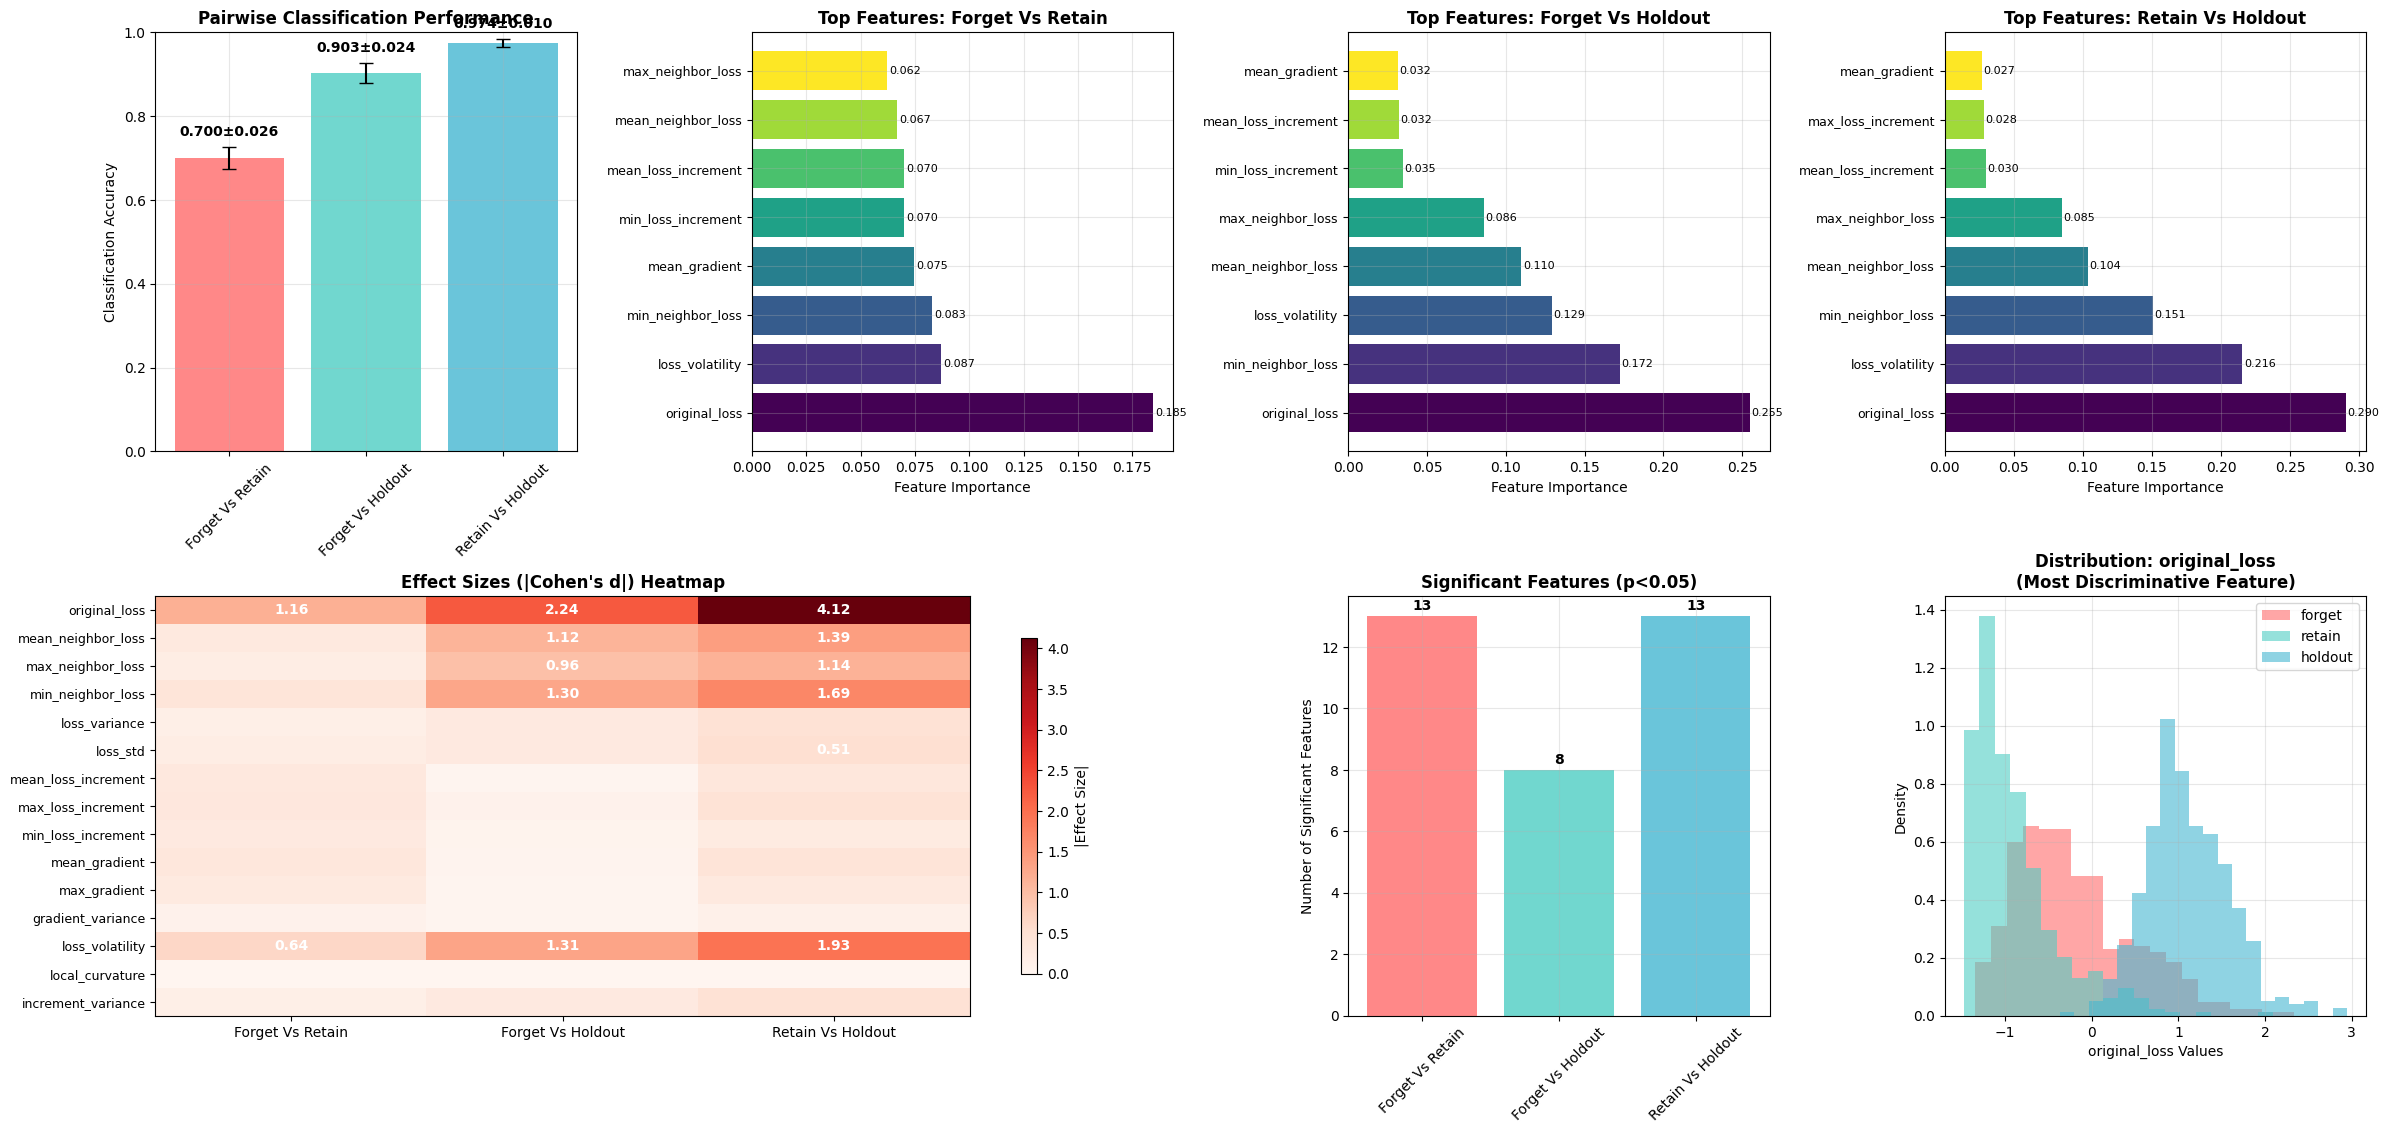


MOST DISCRIMINATIVE FEATURE ACROSS ALL PAIRS: original_loss
Average effect size: 2.509


In [ ]:
# Plot comprehensive pairwise discrimination results
best_discriminative_feature, feature_discrimination_scores = eval_with_ILL.plot_pairwise_discrimination_results(pairwise_results, features_labels, norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

print(f"\nMOST DISCRIMINATIVE FEATURE ACROSS ALL PAIRS: {best_discriminative_feature}")
print(f"Average effect size: {feature_discrimination_scores[best_discriminative_feature]:.3f}")

In [ ]:
# ============================================================================
# COMPREHENSIVE ILL DISCRIMINATION SUMMARY
# ============================================================================

def create_ill_discrimination_summary_report(ill_discrimination, boundary_results, pairwise_results, 
                                            best_discriminative_feature, feature_discrimination_scores):
    """
    Generate a comprehensive summary report for ILL-based dataset discrimination.
    """
    print("="*80)
    print("COMPREHENSIVE INPUT LOSS LANDSCAPE (ILL) DISCRIMINATION REPORT")
    print("="*80)
    
    # Overall discrimination performance
    print("\n1. OVERALL DISCRIMINATION PERFORMANCE:")
    print("-" * 50)
    overall_cv = ill_discrimination['cv_scores'].mean()
    overall_std = ill_discrimination['cv_scores'].std()
    print(f"3-way classification (Forget/Retain/Holdout): {overall_cv:.3f} ± {overall_std:.3f}")
    
    print("\nClassifier comparison:")
    for clf_name, results in boundary_results.items():
        print(f"  {clf_name:15}: {results['cv_mean']:.3f} ± {results['cv_std']:.3f}")
    
    # Feature importance summary
    print("\n2. MOST DISCRIMINATIVE ILL FEATURES:")
    print("-" * 50)
    top_features = ill_discrimination['feature_importance'].head(5)
    for idx, row in top_features.iterrows():
        print(f"{row['rank']}. {row['feature']:20}: {row['importance']:.4f}")
    
    # Feature category analysis
    print("\n3. FEATURE CATEGORY DISCRIMINATION POWER:")
    print("-" * 50)
    feature_categories = {
        'Loss-based': ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss'],
        'Variance-based': ['loss_variance', 'loss_std', 'increment_variance'],
        'Gradient-based': ['mean_gradient', 'max_gradient', 'gradient_variance'],
        'Landscape': ['loss_volatility', 'local_curvature'],
        'Increment-based': ['mean_loss_increment', 'max_loss_increment', 'min_loss_increment']
    }
    
    category_importance = {}
    for category, features in feature_categories.items():
        category_features = ill_discrimination['feature_importance'][
            ill_discrimination['feature_importance']['feature'].isin(features)
        ]
        category_importance[category] = category_features['importance'].sum()
    
    sorted_categories = sorted(category_importance.items(), key=lambda x: x[1], reverse=True)
    for category, importance in sorted_categories:
        print(f"  {category:15}: {importance:.4f}")
    
    # Pairwise discrimination
    print("\n4. PAIRWISE DISCRIMINATION RESULTS:")
    print("-" * 50)
    for pair_name, results in pairwise_results.items():
        acc = results['classification_accuracy']
        std = results['classification_std']
        n_sig = len(results['significant_features'])
        print(f"{pair_name.replace('_', ' ').title():20}: {acc:.3f}±{std:.3f} ({n_sig} significant features)")
    
    # Best discriminative features
    print(f"\n5. MOST DISCRIMINATIVE FEATURE OVERALL:")
    print("-" * 50)
    print(f"Feature: {best_discriminative_feature}")
    print(f"Average effect size across all pairs: {feature_discrimination_scores[best_discriminative_feature]:.3f}")
    
    # Recommendations
    print("\n6. RECOMMENDATIONS FOR ILL-BASED DISCRIMINATION:")
    print("-" * 50)
    
    best_pair = max(pairwise_results.items(), key=lambda x: x[1]['classification_accuracy'])
    worst_pair = min(pairwise_results.items(), key=lambda x: x[1]['classification_accuracy'])
    
    print(f"• Easiest to distinguish: {best_pair[0].replace('_', ' ')} ({best_pair[1]['classification_accuracy']:.3f})")
    print(f"• Hardest to distinguish: {worst_pair[0].replace('_', ' ')} ({worst_pair[1]['classification_accuracy']:.3f})")
    
    print(f"• Focus on top 3 features: {', '.join(top_features.head(3)['feature'].tolist())}")
    
    most_important_category = sorted_categories[0][0]
    print(f"• Most important feature category: {most_important_category}")
    
    # Best classifier
    best_classifier = max(boundary_results.items(), key=lambda x: x[1]['cv_mean'])
    print(f"• Best performing classifier: {best_classifier[0]} ({best_classifier[1]['cv_mean']:.3f})")
    
    print("\n" + "="*80)
    
    # Save comprehensive results
    comprehensive_ill_results = {
        'discrimination_analysis': ill_discrimination,
        'boundary_analysis': boundary_results,
        'pairwise_analysis': pairwise_results,
        'best_discriminative_feature': best_discriminative_feature,
        'feature_discrimination_scores': feature_discrimination_scores,
        'feature_categories': feature_categories,
        'category_importance': category_importance
    }
    
    results_file = f'{plots_base_dir}/comprehensive_ill_discrimination_results.pkl'
    with open(results_file, 'wb') as f:
        pickle.dump(comprehensive_ill_results, f)
    
    print(f"Complete ILL discrimination results saved to: {results_file}")
    
    return comprehensive_ill_results

# Generate comprehensive ILL discrimination summary
comprehensive_ill_results = create_ill_discrimination_summary_report(
    ill_discrimination, boundary_results, pairwise_results, 
    best_discriminative_feature, feature_discrimination_scores
)

print("\n" + "="*60)
print("ILL DISCRIMINATION ANALYSIS COMPLETE!")
print("="*60)
print("Generated specialized plots:")
print("1. ILL feature importance and discrimination analysis")
print("2. Pairwise discrimination comprehensive analysis")
print("3. Confusion matrices and cross-validation results")
print("4. Feature category importance analysis")
print("5. Decision boundary complexity analysis")
print("="*60)

COMPREHENSIVE INPUT LOSS LANDSCAPE (ILL) DISCRIMINATION REPORT

1. OVERALL DISCRIMINATION PERFORMANCE:
--------------------------------------------------
3-way classification (Forget/Retain/Holdout): 0.736 ± 0.009

Classifier comparison:
  Linear SVM     : 0.757 ± 0.021
  RBF SVM        : 0.745 ± 0.017
  Decision Tree  : 0.688 ± 0.014
  Naive Bayes    : 0.723 ± 0.026
  Random Forest  : 0.734 ± 0.006

2. MOST DISCRIMINATIVE ILL FEATURES:
--------------------------------------------------
1. original_loss       : 0.2180
2. loss_volatility     : 0.1226
3. min_neighbor_loss   : 0.1181
4. mean_neighbor_loss  : 0.0899
5. max_neighbor_loss   : 0.0664

3. FEATURE CATEGORY DISCRIMINATION POWER:
--------------------------------------------------
  Loss-based     : 0.4924
  Increment-based: 0.1546
  Gradient-based : 0.1268
  Landscape      : 0.1226
  Variance-based : 0.1036

4. PAIRWISE DISCRIMINATION RESULTS:
--------------------------------------------------
Forget Vs Retain    : 0.700±0.026 (1

In [ ]:
# Specialized Input Loss Landscape (ILL) Analysis Functions

def analyze_loss_landscape_categories(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels):
    """
    Analyze loss landscape features by semantic categories relevant to ILL.
    """
    # Define feature categories for ILL analysis
    feature_categories = {
        'Base Loss': ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss'],
        'Variability': ['loss_variance', 'loss_std', 'increment_variance'],
        'Gradient': ['mean_gradient', 'max_gradient', 'gradient_variance'],
        'Landscape': ['loss_volatility', 'local_curvature'],
        'Increment': ['mean_loss_increment', 'max_loss_increment', 'min_loss_increment']
    }
    
    datasets = {
        'retain': norm_retain_tensor,
        'holdout': norm_holdout_tensor,
        'forget': norm_forget_tensor
    }
    
    category_analysis = {}
    
    # Analyze each category
    for category, features in feature_categories.items():
        category_data = {}
        
        for dataset_name, tensor in datasets.items():
            category_features = []
            for feature in features:
                if feature in features_labels:
                    feat_idx = features_labels.index(feature)
                    category_features.append(tensor[:, feat_idx].numpy())
            
            if category_features:
                category_tensor = np.column_stack(category_features)
                
                # Compute category-level statistics
                category_data[dataset_name] = {
                    'mean_values': np.mean(category_tensor, axis=0),
                    'std_values': np.std(category_tensor, axis=0),
                    'category_mean': np.mean(category_tensor),
                    'category_std': np.std(category_tensor),
                    'feature_correlations': np.corrcoef(category_tensor.T),
                    'feature_names': [f for f in features if f in features_labels]
                }
        
        category_analysis[category] = category_data
    
    return category_analysis

# Run category analysis
print("Analyzing ILL features by semantic categories...")
category_analysis = analyze_loss_landscape_categories(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor, features_labels)

Analyzing ILL features by semantic categories...


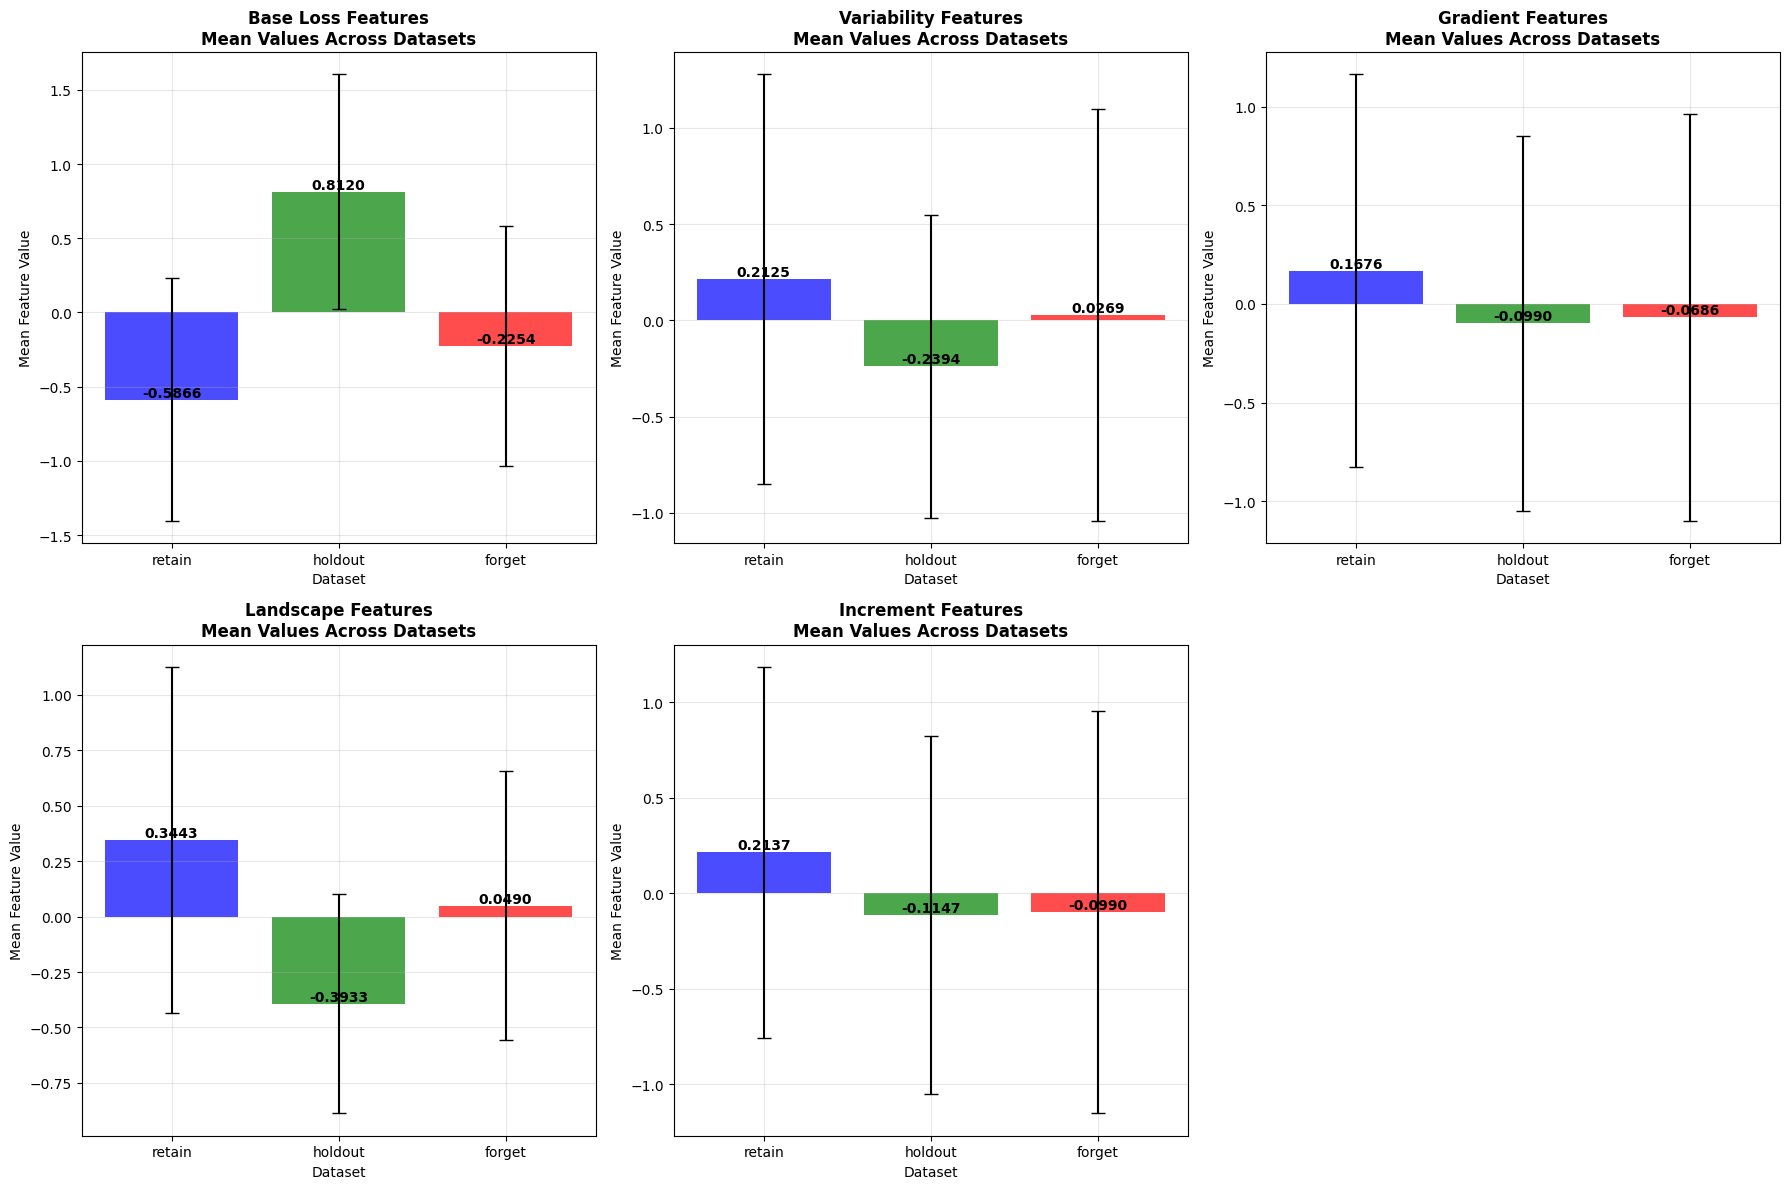

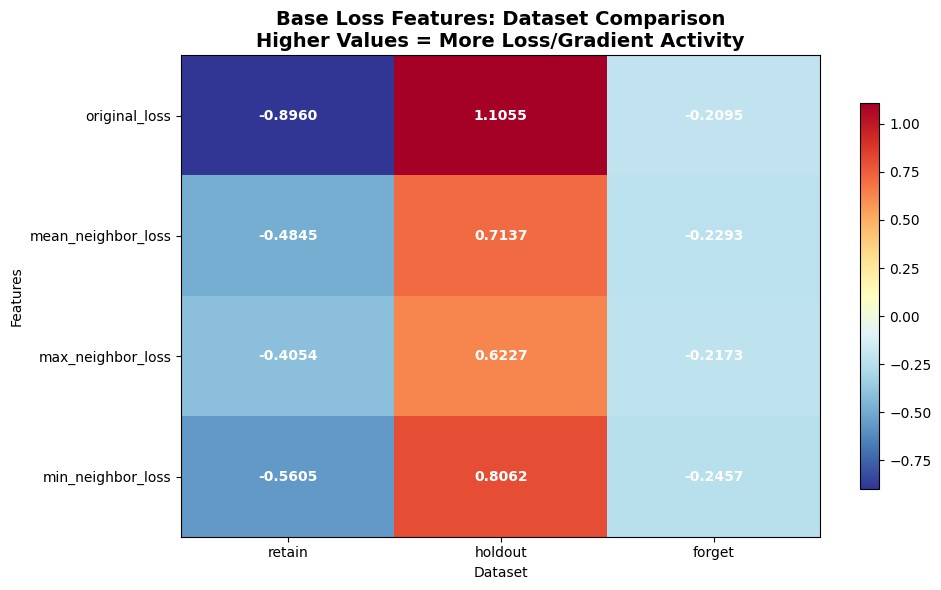

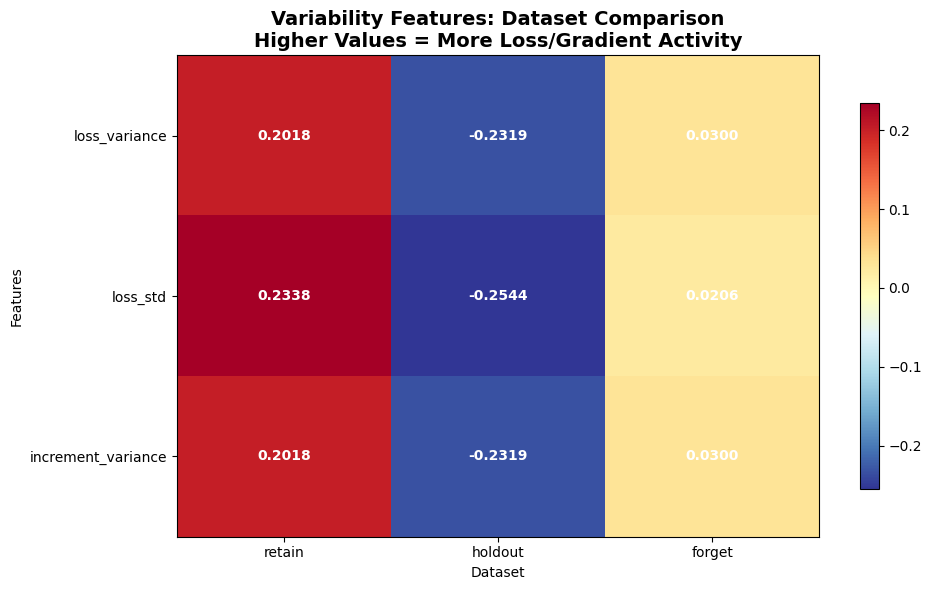

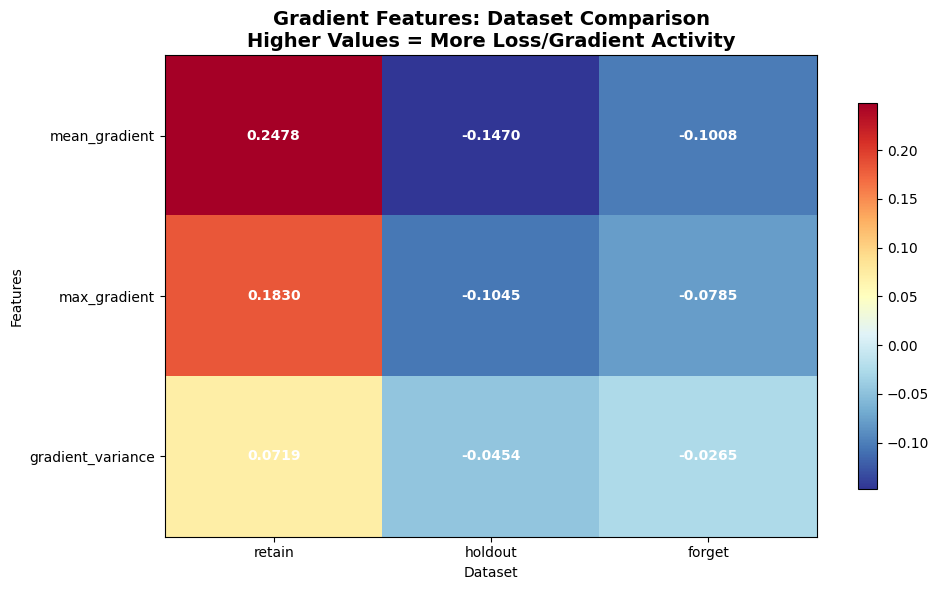

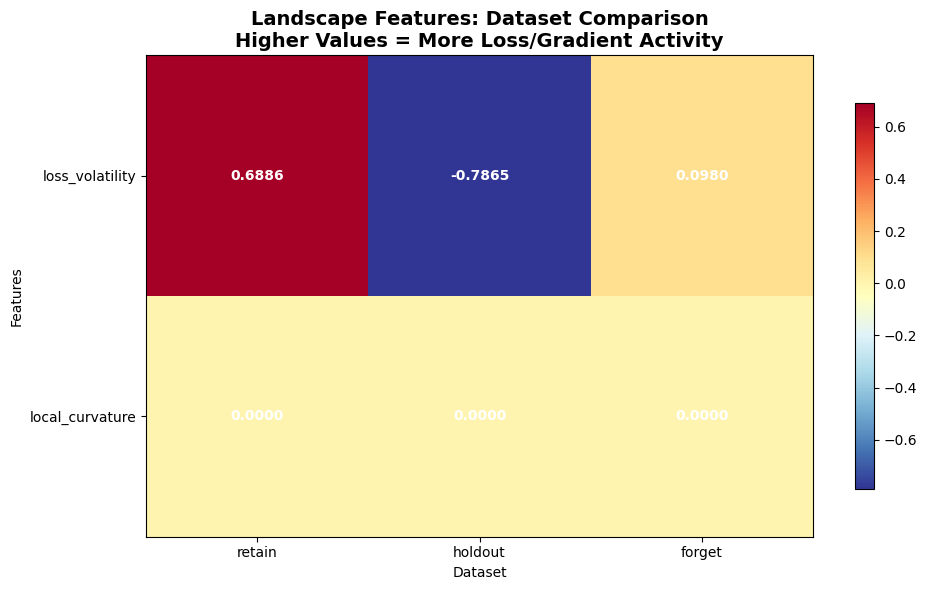

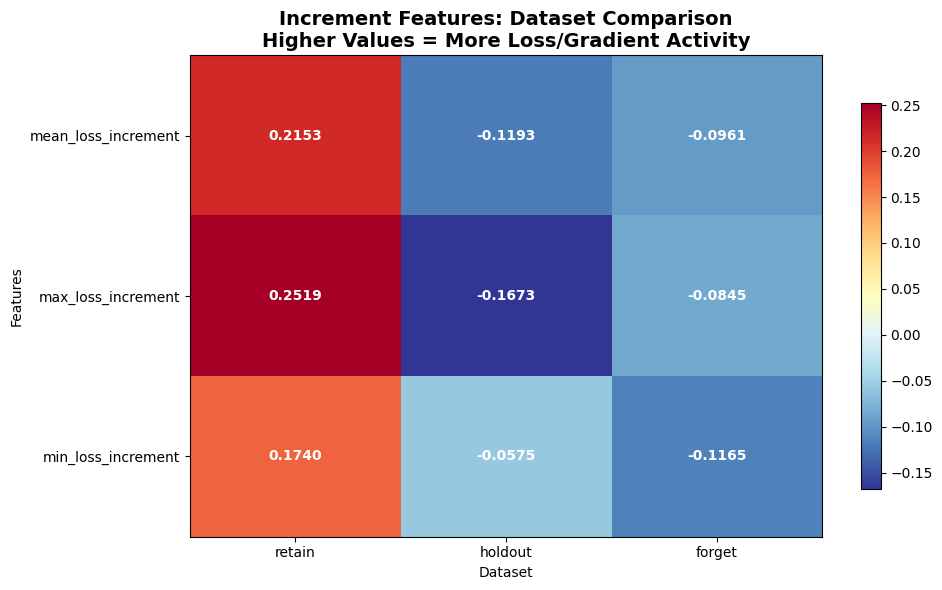

In [ ]:
# Visualize ILL Category Analysis
def plot_ill_category_analysis(category_analysis):
    """
    Create comprehensive visualizations for ILL category analysis.
    """
    categories = list(category_analysis.keys())
    datasets = ['retain', 'holdout', 'forget']
    colors = {'retain': 'blue', 'holdout': 'green', 'forget': 'red'}
    
    # 1. Category-level means comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, category in enumerate(categories):
        ax = axes[idx]
        
        category_means = []
        category_stds = []
        
        for dataset in datasets:
            if dataset in category_analysis[category]:
                category_means.append(category_analysis[category][dataset]['category_mean'])
                category_stds.append(category_analysis[category][dataset]['category_std'])
            else:
                category_means.append(0)
                category_stds.append(0)
        
        x_pos = np.arange(len(datasets))
        bars = ax.bar(x_pos, category_means, yerr=category_stds, 
                     color=[colors[d] for d in datasets], alpha=0.7, capsize=5)
        
        ax.set_title(f'{category} Features\nMean Values Across Datasets', fontweight='bold')
        ax.set_xlabel('Dataset')
        ax.set_ylabel('Mean Feature Value')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(datasets)
        ax.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, mean_val in zip(bars, category_means):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{mean_val:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # Hide unused subplot
    if len(categories) < len(axes):
        axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{plots_base_dir}/ill_category_means.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    # 2. Feature-level heatmap for each category
    for category in categories:
        if category not in category_analysis:
            continue
            
        # Get feature names for this category
        feature_names = None
        for dataset in datasets:
            if dataset in category_analysis[category]:
                feature_names = category_analysis[category][dataset]['feature_names']
                break
        
        if not feature_names:
            continue
            
        # Create data matrix
        data_matrix = []
        for feature_idx in range(len(feature_names)):
            row = []
            for dataset in datasets:
                if dataset in category_analysis[category]:
                    row.append(category_analysis[category][dataset]['mean_values'][feature_idx])
                else:
                    row.append(0)
            data_matrix.append(row)
        
        data_matrix = np.array(data_matrix)
        
        # Plot heatmap
        fig, ax = plt.subplots(figsize=(10, max(6, len(feature_names)*0.8)))
        im = ax.imshow(data_matrix, cmap='RdYlBu_r', aspect='auto')
        
        ax.set_title(f'{category} Features: Dataset Comparison\nHigher Values = More Loss/Gradient Activity', 
                    fontweight='bold', fontsize=14)
        ax.set_xlabel('Dataset')
        ax.set_ylabel('Features')
        ax.set_xticks(range(len(datasets)))
        ax.set_yticks(range(len(feature_names)))
        ax.set_xticklabels(datasets)
        ax.set_yticklabels(feature_names)
        
        # Add text annotations
        for i in range(len(feature_names)):
            for j in range(len(datasets)):
                text = ax.text(j, i, f'{data_matrix[i, j]:.4f}',
                              ha="center", va="center", color="white", fontweight='bold')
        
        plt.colorbar(im, ax=ax, shrink=0.8)
        plt.tight_layout()
        plt.savefig(f'{plots_base_dir}/ill_{category.lower()}_features.png', bbox_inches='tight', dpi=150)
        plt.show()

# Plot ILL category analysis
plot_ill_category_analysis(category_analysis)

In [ ]:
# Sentence Embedding Analysis for Semantic Landscape
def analyze_semantic_embeddings(forget_data, holdout_data, retain_data):
    """
    Analyze sentence embeddings to understand semantic patterns in loss landscapes.
    """
    from sentence_transformers import SentenceTransformer
    
    # Load a sentence transformer model
    try:
        embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
        print("Using SentenceTransformer for semantic analysis...")
    except:
        print("SentenceTransformer not available. Install with: pip install sentence-transformers")
        return None
    
    # Extract texts from data
    datasets = {
        'forget': [item['text'] for item in forget_data if item.get('valid_example', True)],
        'holdout': [item['text'] for item in holdout_data if item.get('valid_example', True)],
        'retain': [item['text'] for item in retain_data if item.get('valid_example', True)]
    }
    
    # Limit to reasonable sample size for computation
    max_samples = 500
    for dataset_name in datasets:
        if len(datasets[dataset_name]) > max_samples:
            datasets[dataset_name] = datasets[dataset_name][:max_samples]
            print(f"Limiting {dataset_name} to {max_samples} samples for embedding analysis")
    
    # Compute embeddings
    embedding_results = {}
    
    for dataset_name, texts in datasets.items():
        print(f"Computing embeddings for {dataset_name} dataset ({len(texts)} samples)...")
        embeddings = embedding_model.encode(texts, show_progress_bar=True)
        
        embedding_results[dataset_name] = {
            'embeddings': embeddings,
            'texts': texts,
            'embedding_mean': np.mean(embeddings, axis=0),
            'embedding_std': np.std(embeddings, axis=0),
            'centroid': np.mean(embeddings, axis=0),
            'intra_cluster_distance': np.mean(pdist(embeddings))
        }
    
    return embedding_results

# Run semantic embedding analysis
print("Analyzing sentence embeddings for semantic landscape patterns...")
try:
    semantic_results = analyze_semantic_embeddings(forget_data, holdout_data, retain_data)
except Exception as e:
    print(f"Semantic analysis failed: {e}")
    print("Continuing with other analyses...")
    semantic_results = None

Analyzing sentence embeddings for semantic landscape patterns...
Using SentenceTransformer for semantic analysis...
Semantic analysis failed: 'str' object has no attribute 'get'
Continuing with other analyses...
Using SentenceTransformer for semantic analysis...
Semantic analysis failed: 'str' object has no attribute 'get'
Continuing with other analyses...
